In [1]:
import numpy as np
import pandas as pd
import xarray as xr

from eda import SensorEDA

In [2]:
def run_eda(ds, name, ref_var=None, entity_dim="sensor"):
    print("\n" + "="*80)
    print(f"RUNNING EDA FOR: {name}")
    print("="*80)

    eda=SensorEDA(ds,ref_var=ref_var,entity_dim=entity_dim)
    eda.clean_dataset()

    print("\n--- DATASET SUMMARY ---")
    print(eda.dataset_summary())

    print("\n--- DATASET STRUCTURE ---")
    print(eda.dataset_structure())

    print("\n--- ENTITY INVENTORY ---")
    print(eda.entity_inventory())

    print("\n--- GLOBAL CADENCE ---")
    print(eda.global_cadence())

    print("\n--- GLOBAL GAPS ---")
    print(eda.global_gaps(gap_threshold_hours=2))

    print("\n--- ENTITY GAPS ---")
    print(eda.entity_gaps(gap_threshold_hours=2))

    print("\n--- MISSINGNESS GLOBAL ---")
    print(eda.missingness_global())

    print("\n--- STATS GLOBAL ---")
    print(eda.stats_global())

    print("\n--- ENTITY VARIABLE STATS (HEAD) ---")
    print(eda.entity_variable_stats().head(10))

    print("\n--- ENTITY LIFECYCLE MISSING (HEAD) ---")
    print(eda.entity_lifecycle_missing().head(10))

    print("\n--- CONDITIONAL MISSING ---")
    print(eda.conditional_missing())
    
    print("\n--- OUTLIER SUMMARY ---")
    print(eda.outlier_summary(per_entity=False))

In [3]:
ds_tharsis = xr.open_dataset("/datassd/proyectos/terravision/terravision_sensor_data/tharsis/tilt/tharsis_tilt_geolocated.nc")

ds_canteras = xr.open_dataset("/datassd/proyectos/terravision/terravision_sensor_data/canteras/canteras_atmos.nc")

In [4]:
run_eda(ds_tharsis, "INCLINOMETERS", ref_var="x_mm_per_m", entity_dim="sensor")

run_eda(ds_canteras, "WEATHER STATION", ref_var="temperatura", entity_dim="sensor")


RUNNING EDA FOR: INCLINOMETERS

--- DATASET SUMMARY ---
{'n_vars': 17, 'n_time': 37331, 'entity_dim': 'sensor', 'n_entities': 15, 'time_start': '2023-08-01 14:59:47', 'time_end': '2026-03-10 10:07:22'}

--- DATASET STRUCTURE ---
{'dims': {'time': 37331, 'sensor': 15}, 'coords': ['time', 'sensor', 'x', 'y'], 'data_vars': ['hops', 'intervals_active', 'mesh_parent', 'radio_signal_strength_incoming_dbm', 'radio_signal_strength_outgoing_dbm', 'packets_queued', 'type', 'radio_connection_group', 'mesh_batt_v', 'ref_v', 'temp_c', 'x_g', 'y_g', 'z_g', 'x_mm_per_m', 'y_mm_per_m', 'z_mm_per_m']}

--- ENTITY INVENTORY ---
      entity  entity_idx          data_start            data_end  count status
0   16221D04           0 2023-08-01 14:59:47 2026-03-10 10:06:20  11199     ok
1   16221F12           4 2023-08-01 14:59:47 2026-03-10 10:06:20  10894     ok
2   16221F19           5 2023-08-01 14:59:47 2026-03-10 10:06:20  10213     ok
3   16222309           7 2023-08-01 14:59:47 2026-03-10 10:06:20 

In [5]:
from IPython.display import display

def run_plots(ds, name, ref_var=None, entity_dim="sensor"):
    print("\n" + "="*80)
    print(f"RUNNING PLOTS FOR: {name}")
    print("="*80)

    eda = SensorEDA(ds, ref_var=ref_var, entity_dim=entity_dim)
    eda.clean_dataset()

    has_entities = entity_dim in ds.dims and ds.sizes.get(entity_dim, 1) > 1

    important_vars_incl = ["x_mm_per_m","y_mm_per_m","z_mm_per_m","x_g","y_g","z_g"]
    important_vars_meteo = ["temperatura","humedad","presion_atmosferica","velocidad_media_del_viento","radiacion_solar"]

    valid_vars = [v for v in eda._get_valid_plot_vars(eda._get_ds())]

    if any(v in valid_vars for v in important_vars_incl):
        vars_to_plot = [v for v in important_vars_incl if v in valid_vars]
    elif any(v in valid_vars for v in important_vars_meteo):
        vars_to_plot = [v for v in important_vars_meteo if v in valid_vars]
    else:
        vars_to_plot = valid_vars

    agg_map = {
        "lluvia": "sum",
        "intensidad_de_lluvia": "sum",
        "rain_mm": "sum",
        "rainfall": "sum"
    }

    max_entities = 10 if has_entities else None

    print("\n--- TIMESERIES PLOTS ---")
    eda.plot_timeseries(
        vars_to_plot=vars_to_plot,
        freq="1D",
        rolling_window=7,
        per_entity=has_entities,
        max_entities=max_entities,
        agg_map=agg_map
    )

    print("\n--- DISTRIBUTION PLOTS ---")
    eda.plot_distributions(
        vars_to_plot=vars_to_plot,
        per_entity=False
    )

    print("\n--- CORRELATION MATRIX (variables) ---")
    eda.plot_correlation_matrix(
        vars_to_plot=vars_to_plot,
        freq="1D",
        agg="median",
        min_non_nan_frac=0.5,
        entity=None
    )

    print("\n--- AVAILABILITY ---")
    eda.plot_availability(
        var=vars_to_plot[0] if vars_to_plot else None,
        freq="1D",
        per_entity=False
    )

    # ==========================================================
    #  MULTISENSOR
    # ==========================================================
    if has_entities and vars_to_plot:

        print("\n--- SENSOR-SENSOR CORRELATION ---")
        eda.plot_entity_correlation_matrix(
            var=vars_to_plot[0],
            freq="1D",
            agg="mean",
            min_non_nan_frac=0.6,
            max_entities=40
        )

        print("\n--- AVAILABILITY HEATMAP ---")
        eda.plot_availability_heatmap(
            var=vars_to_plot[0],
            freq="1D",
            max_entities=80
        )

        print("\n--- OVERLAY SENSORS ---")
        for v in vars_to_plot:
            eda.plot_variable_overlay(
                var=v,
                freq="1D",
                agg="mean",
                rolling_window=7,
                max_entities=60
            )

        print("\n--- BOXPLOT BY SENSOR ---")
        for v in vars_to_plot:
            eda.plot_boxplot_by_entity(
                var=v,
                max_entities=50
            )

    return eda


RUNNING PLOTS FOR: INCLINOMETERS

--- TIMESERIES PLOTS ---


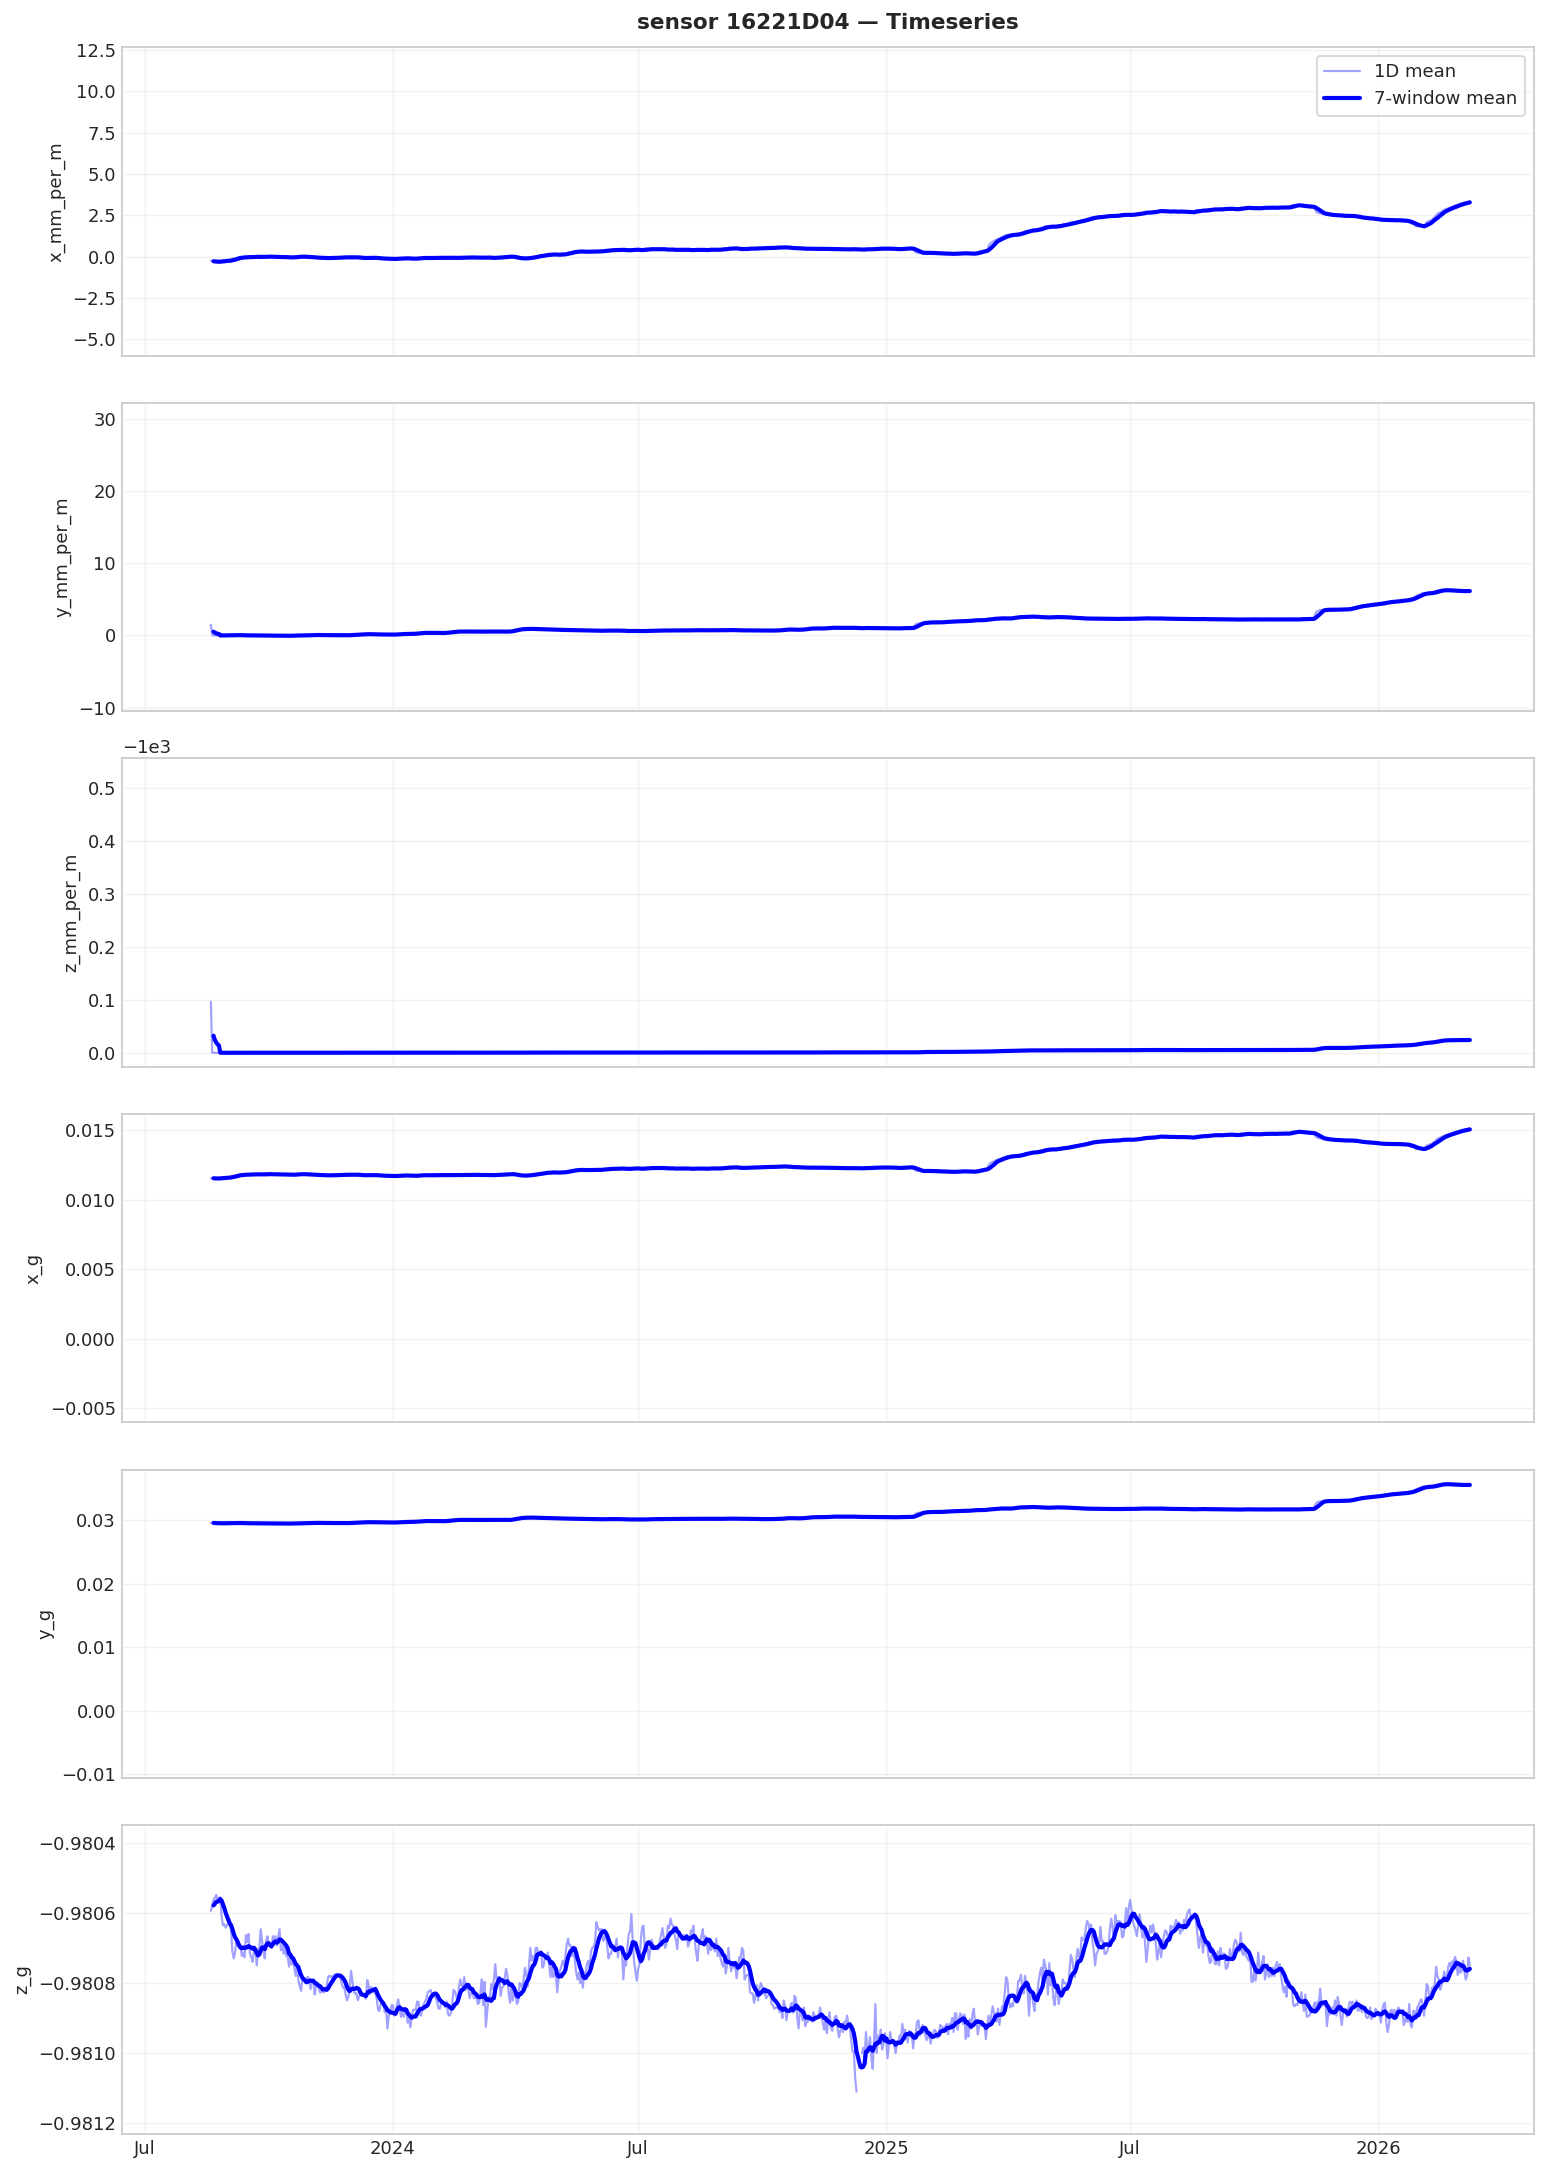

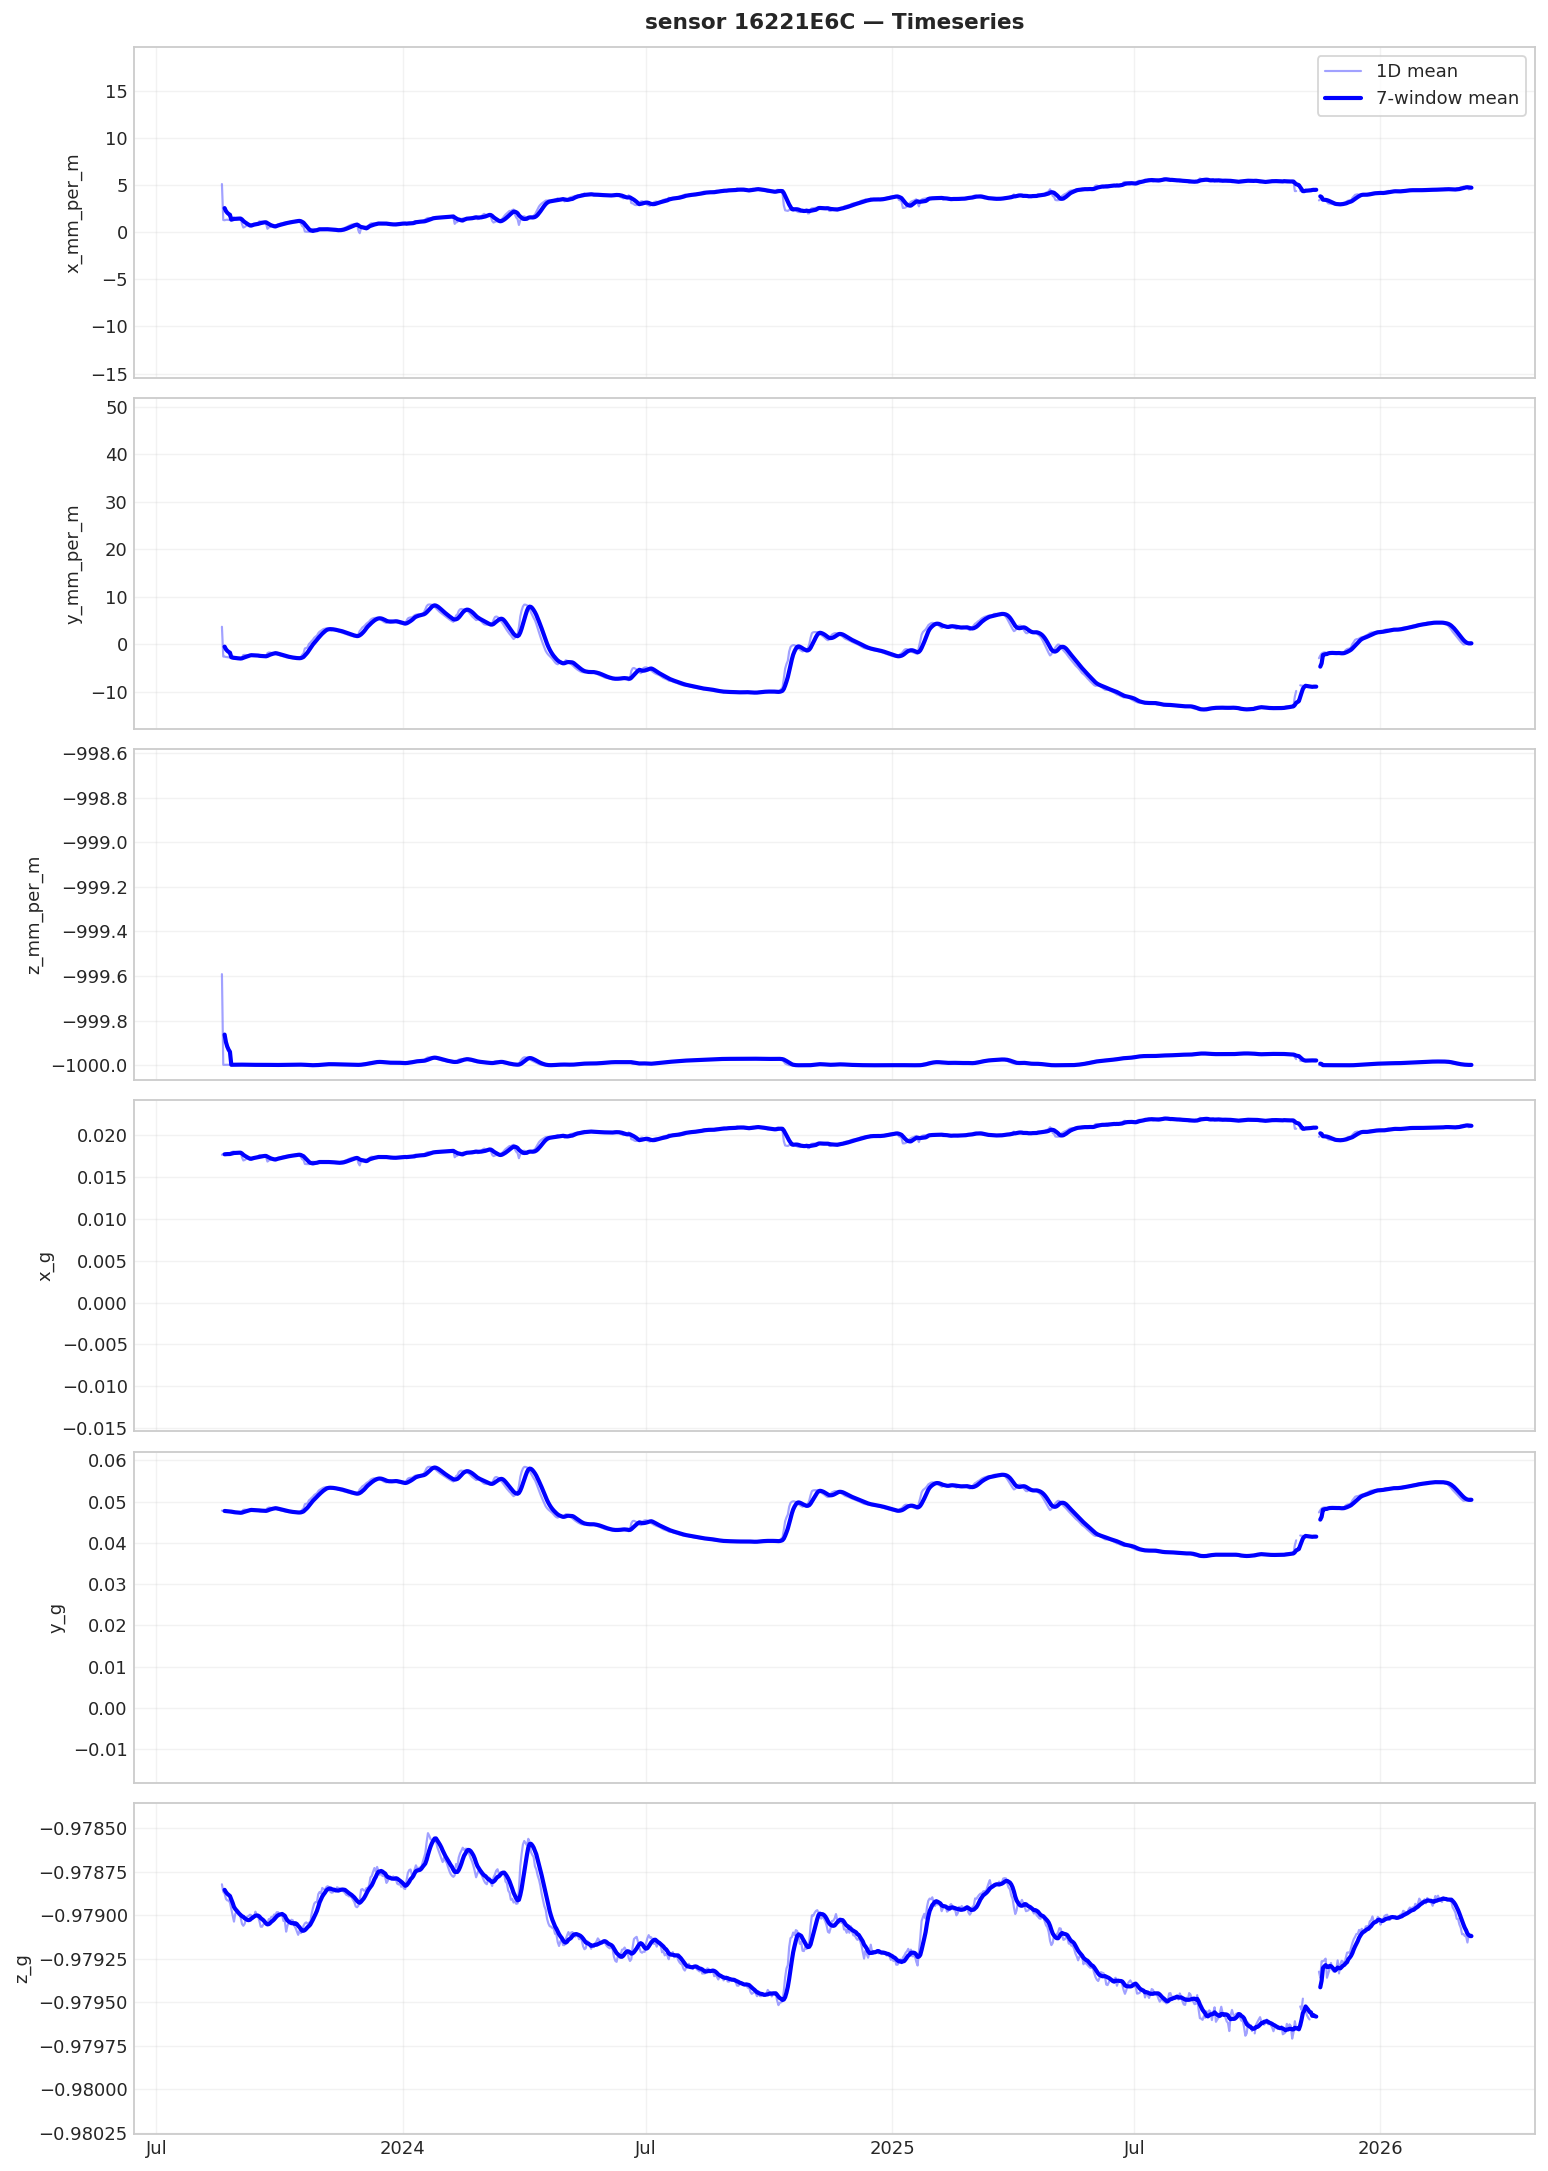

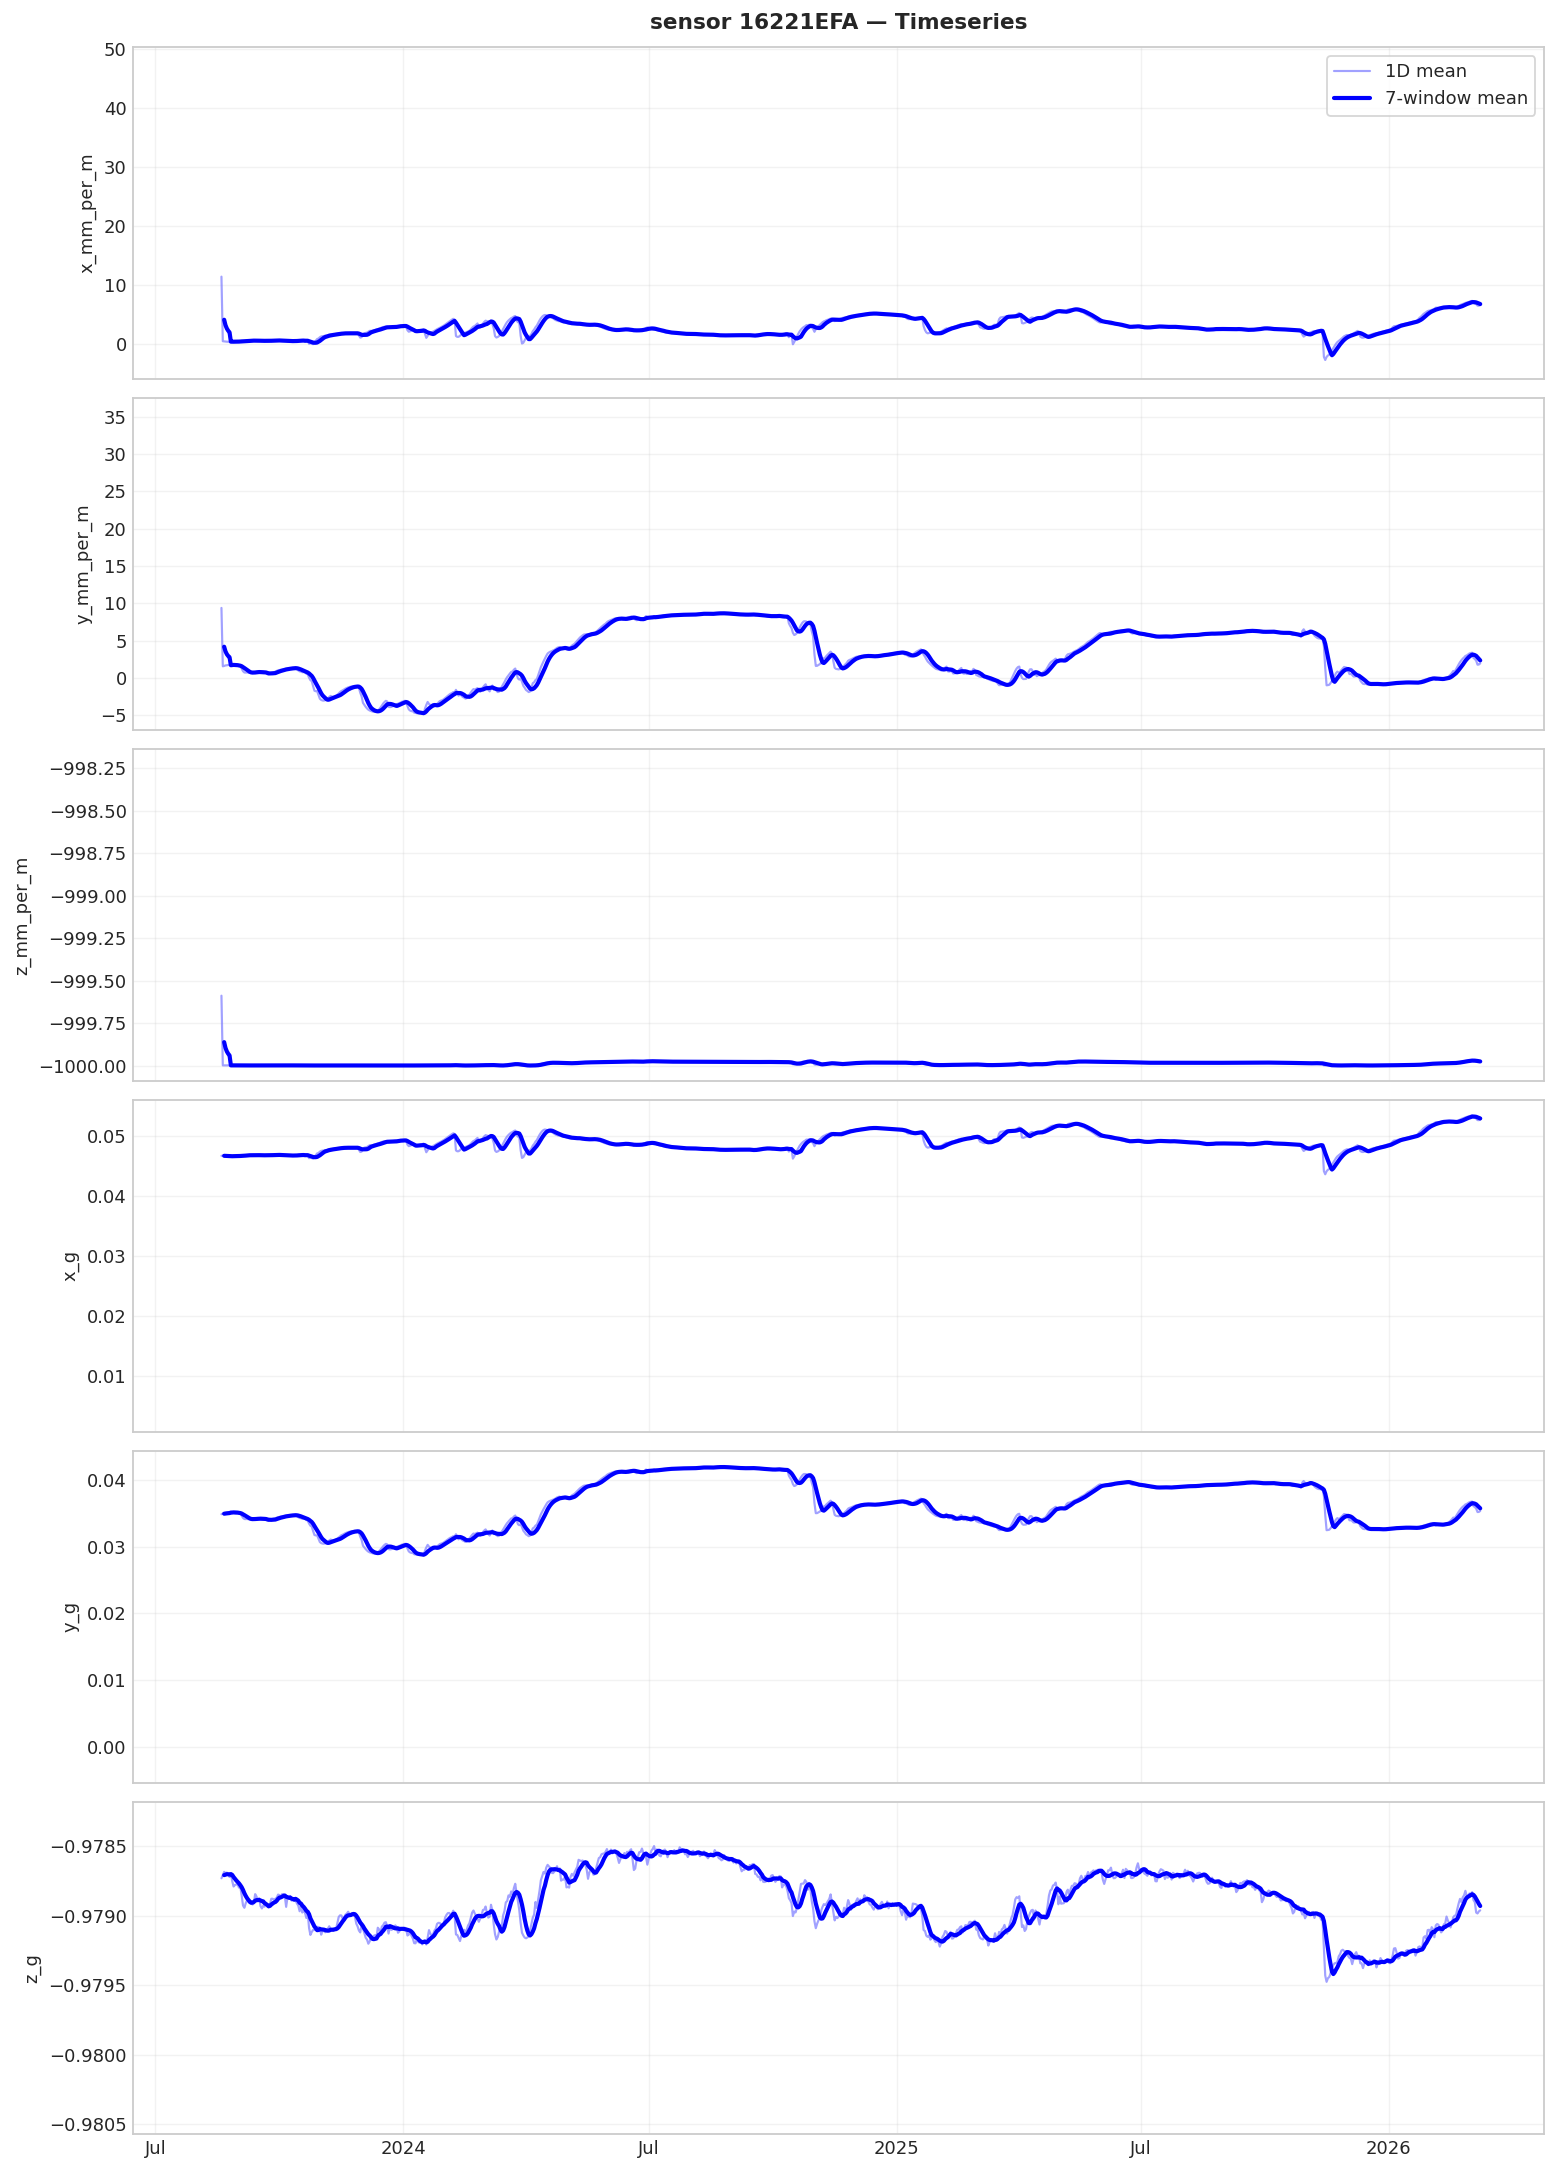

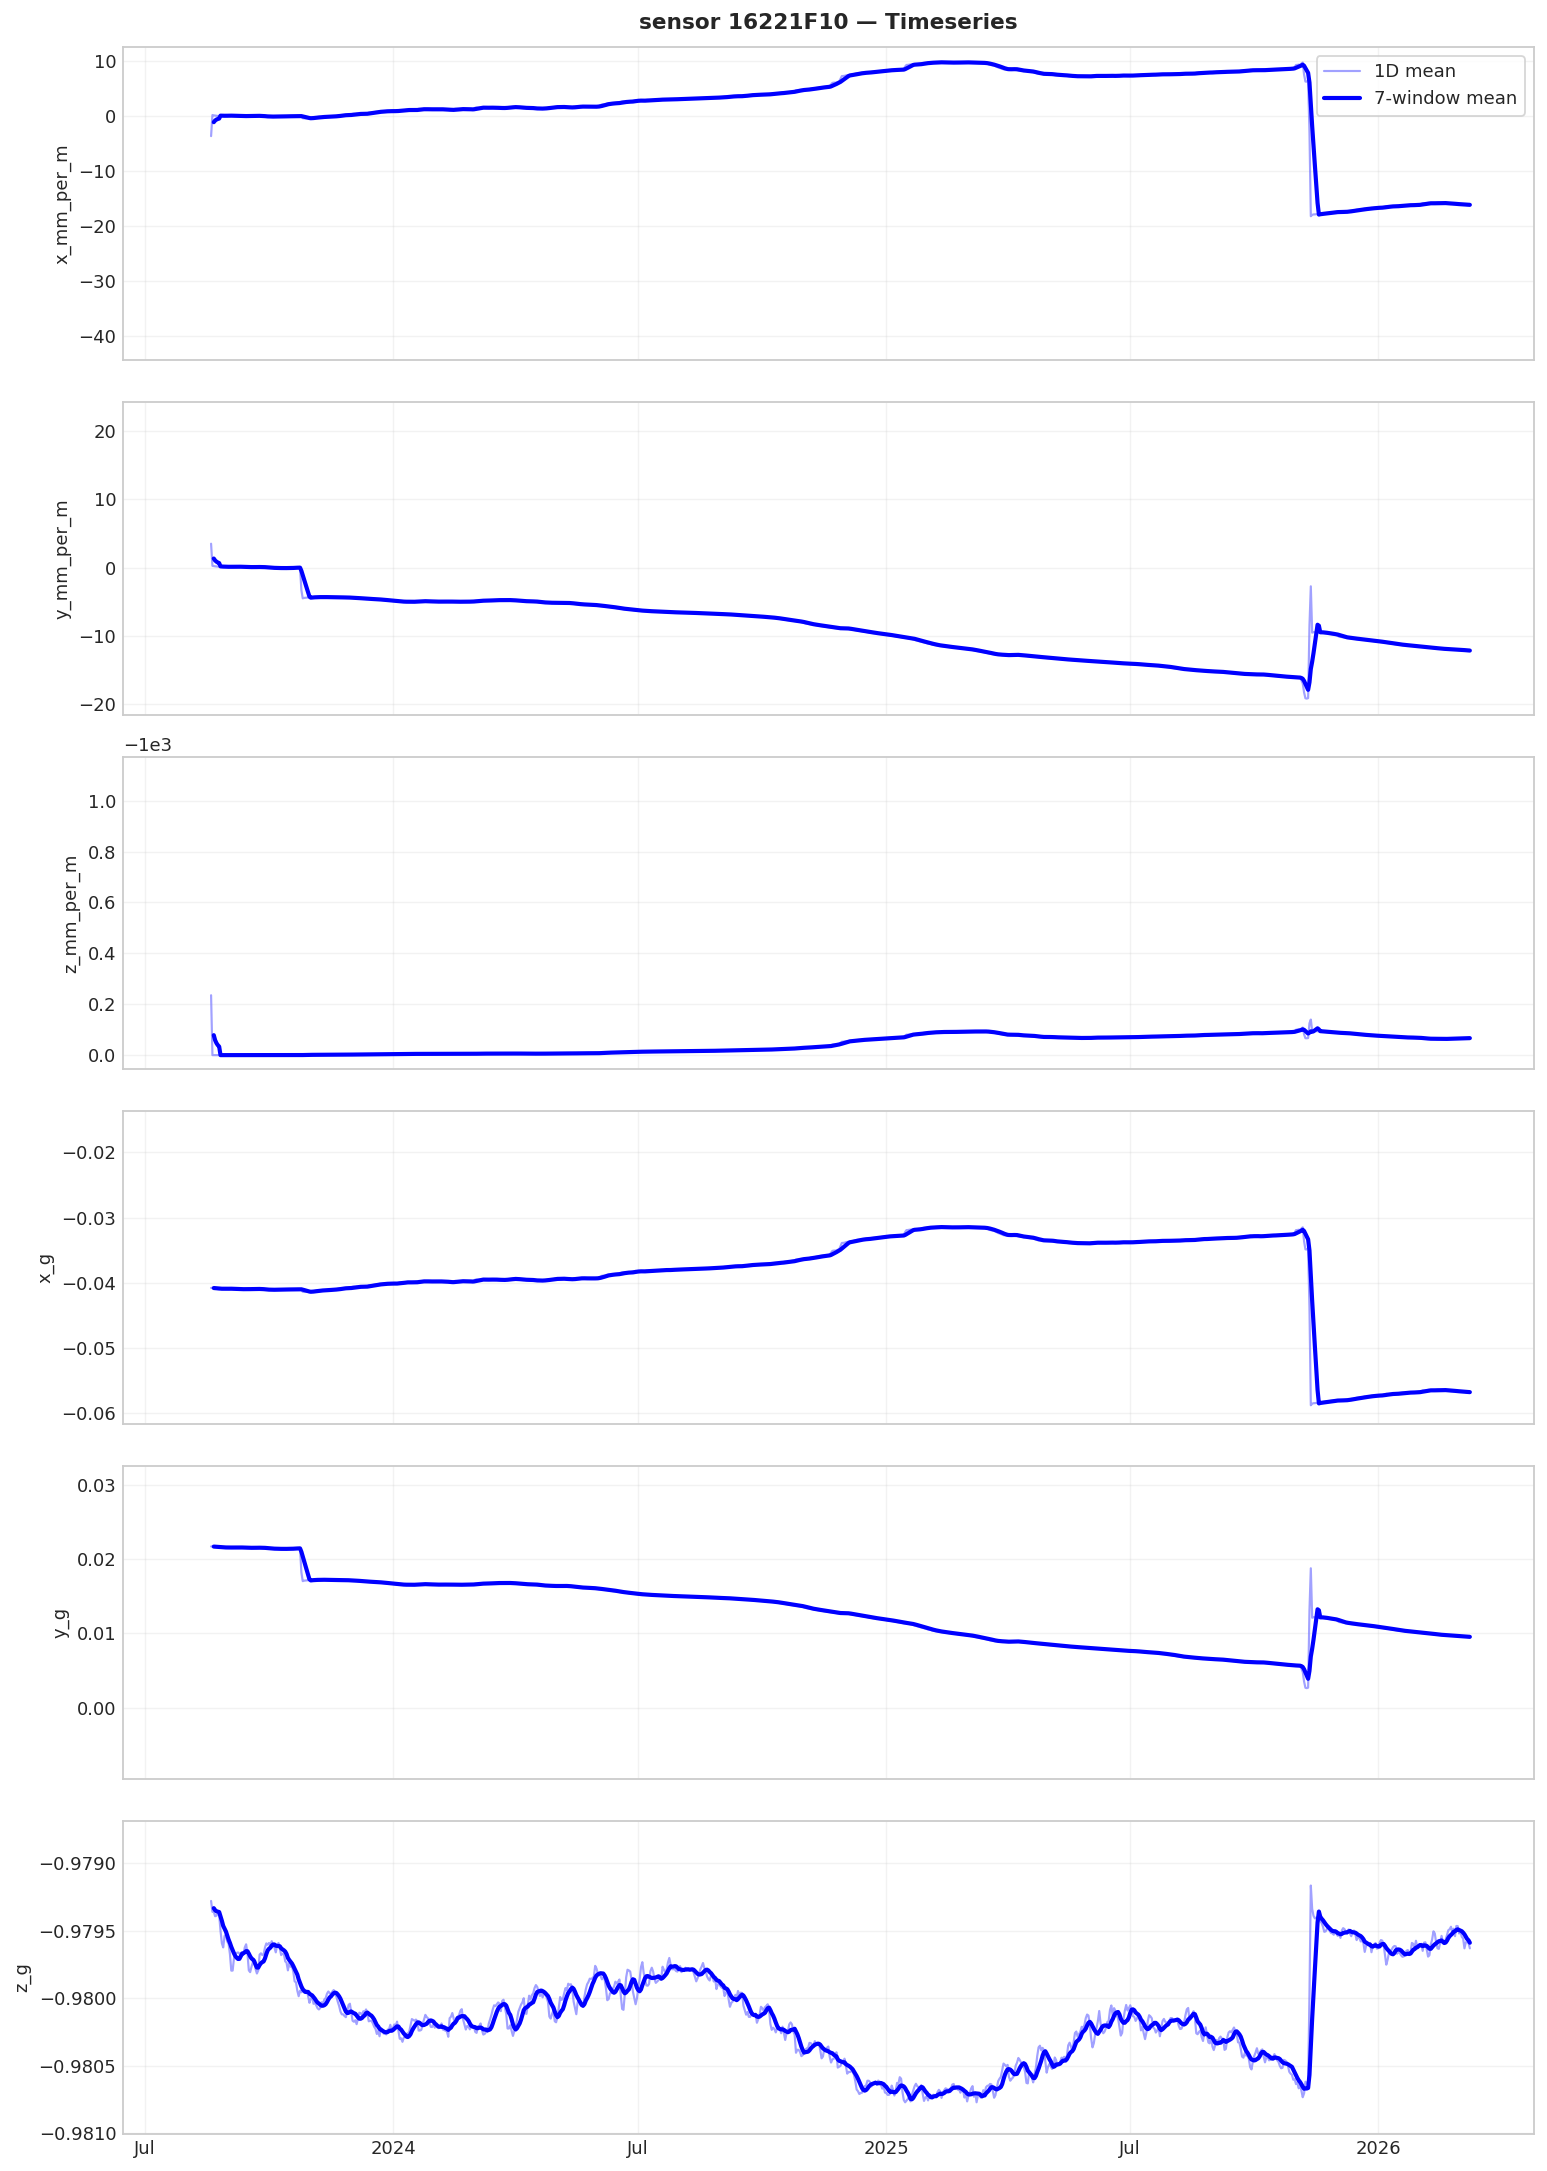

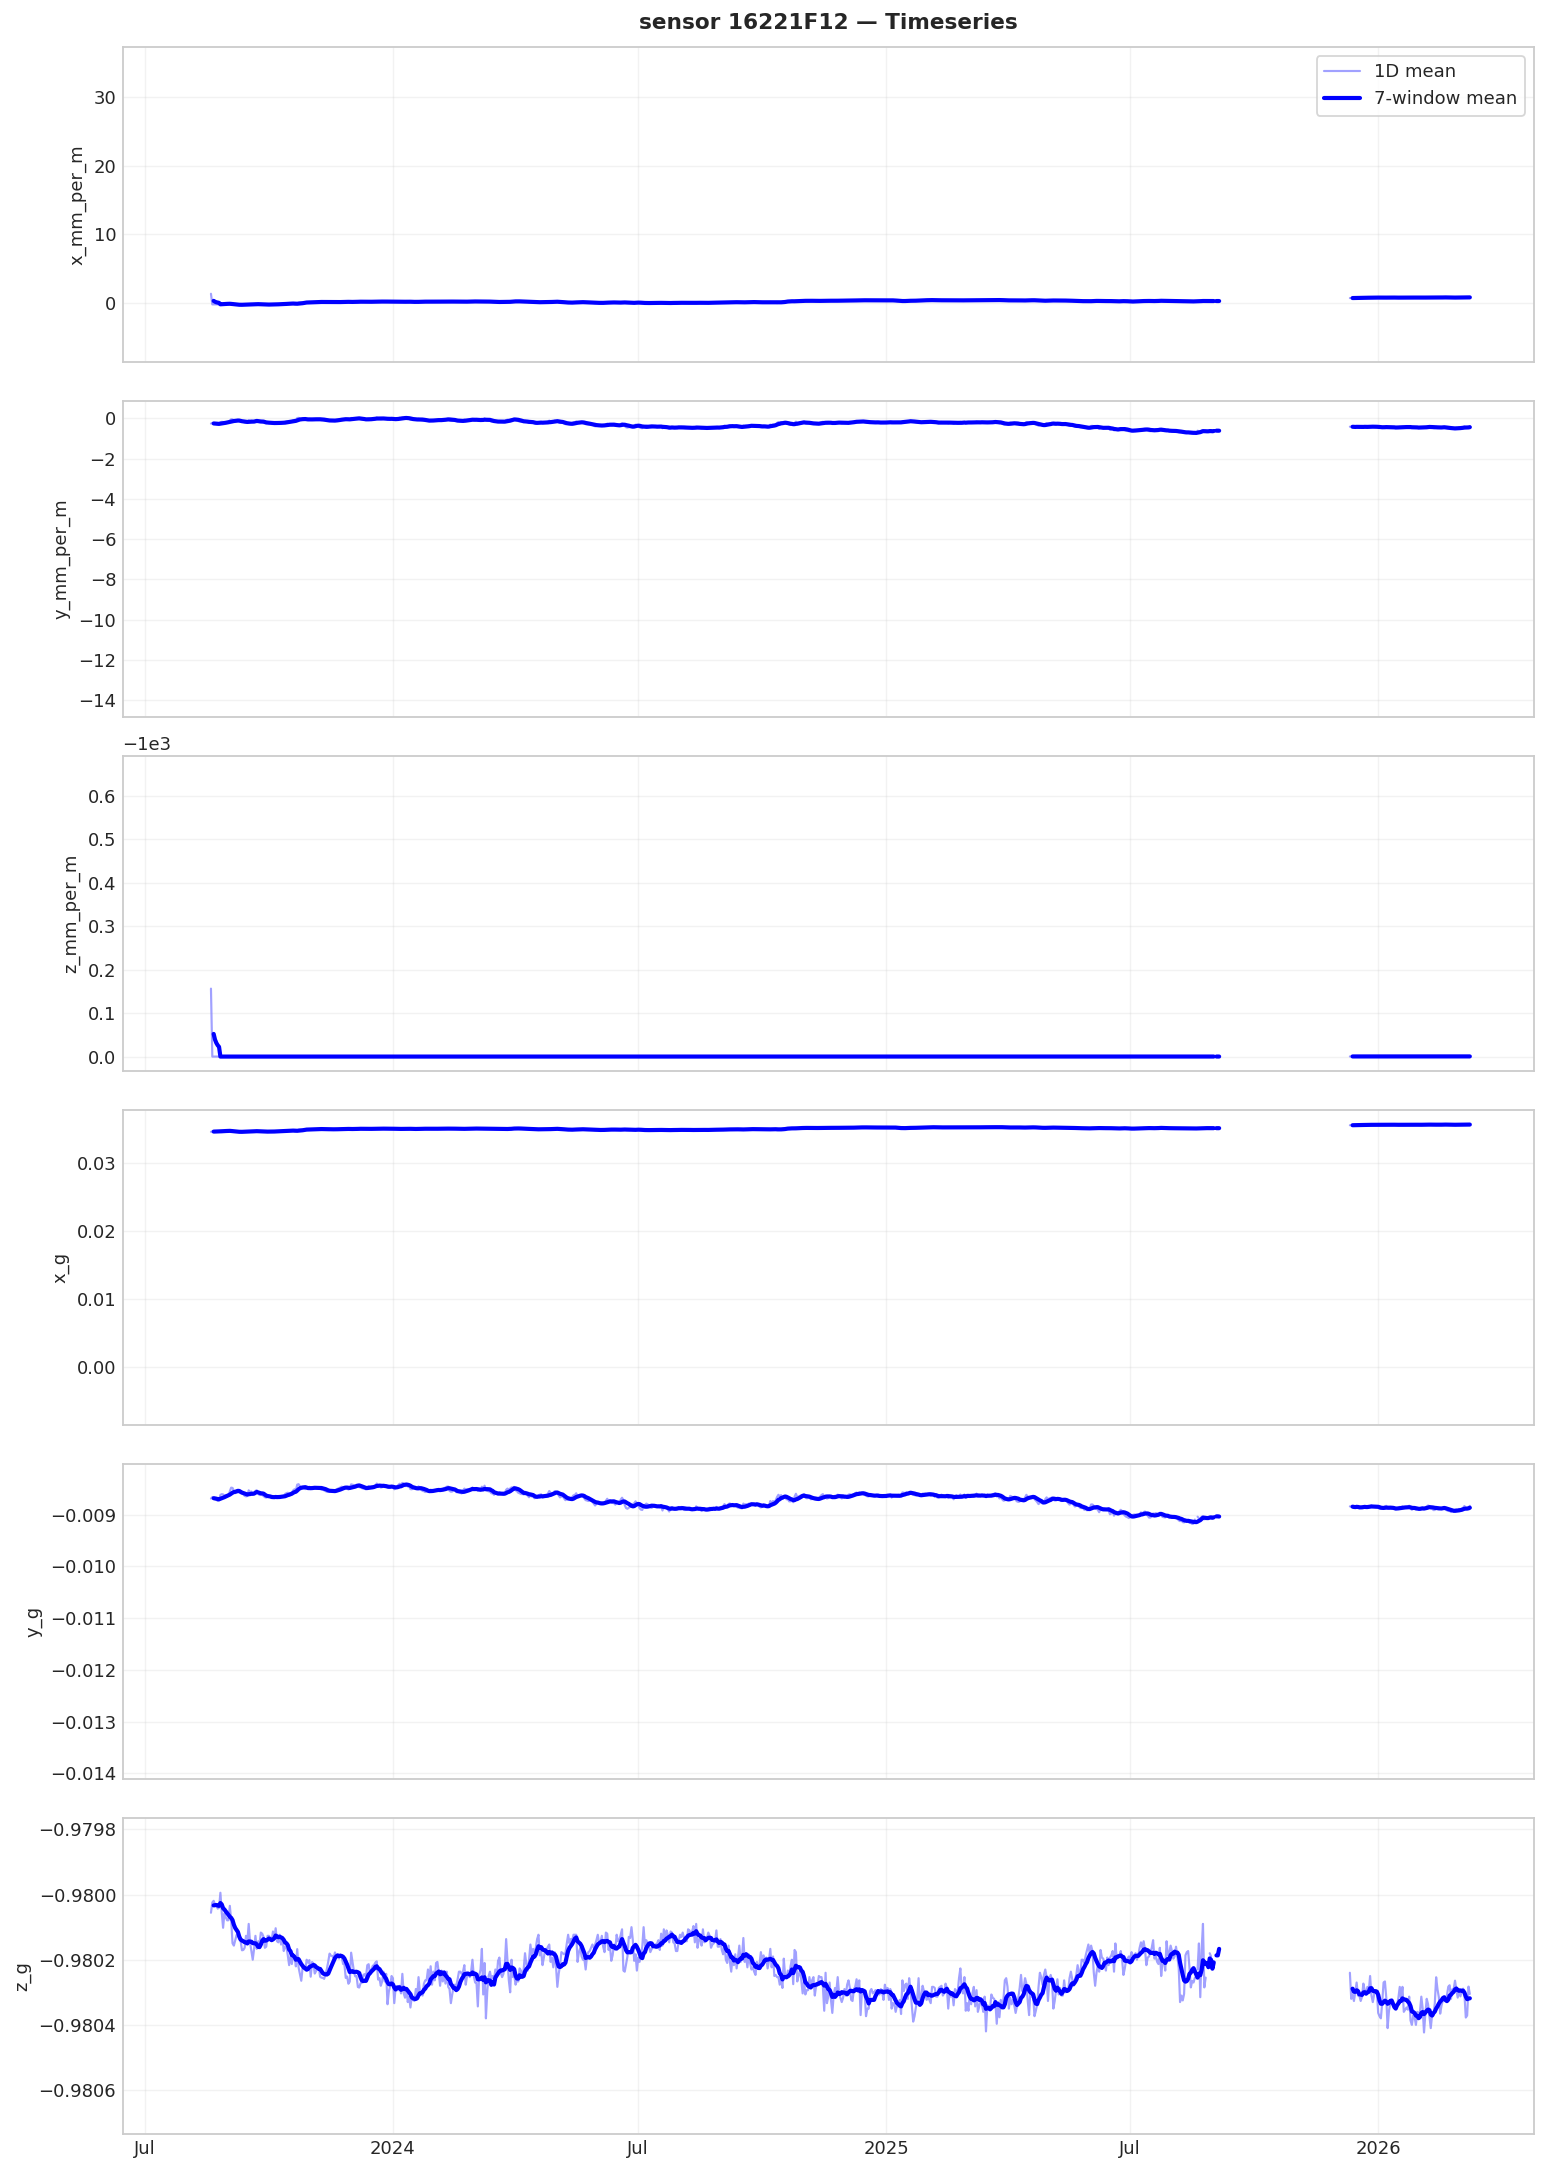

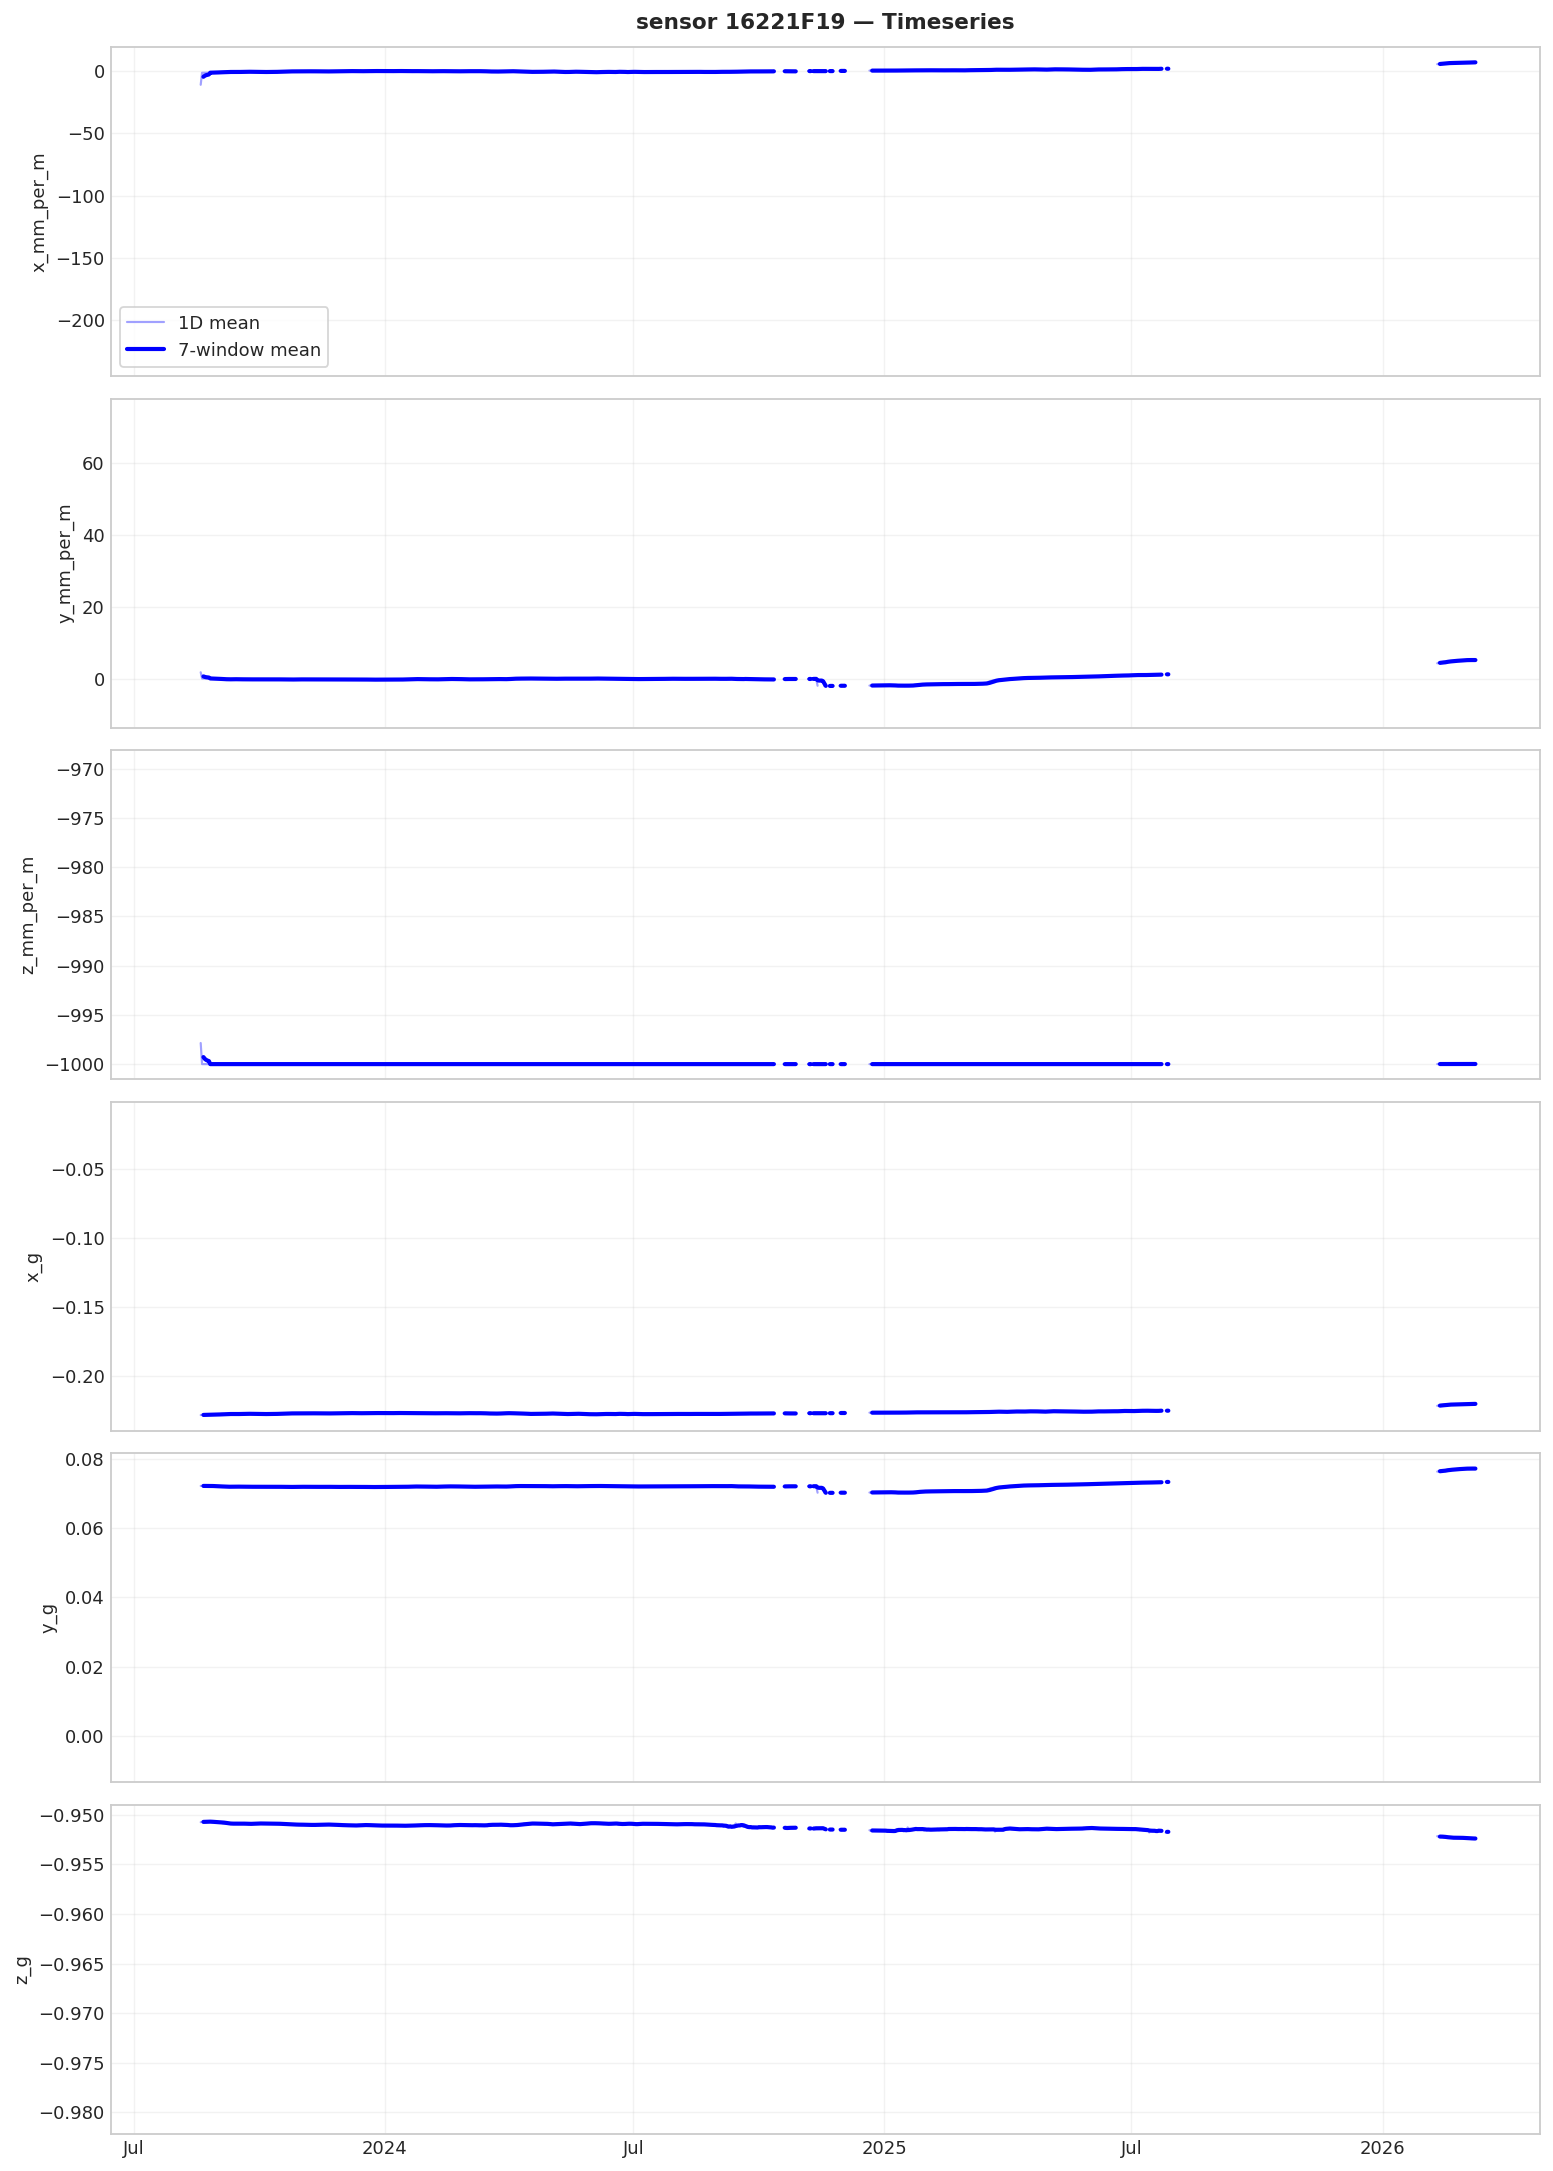

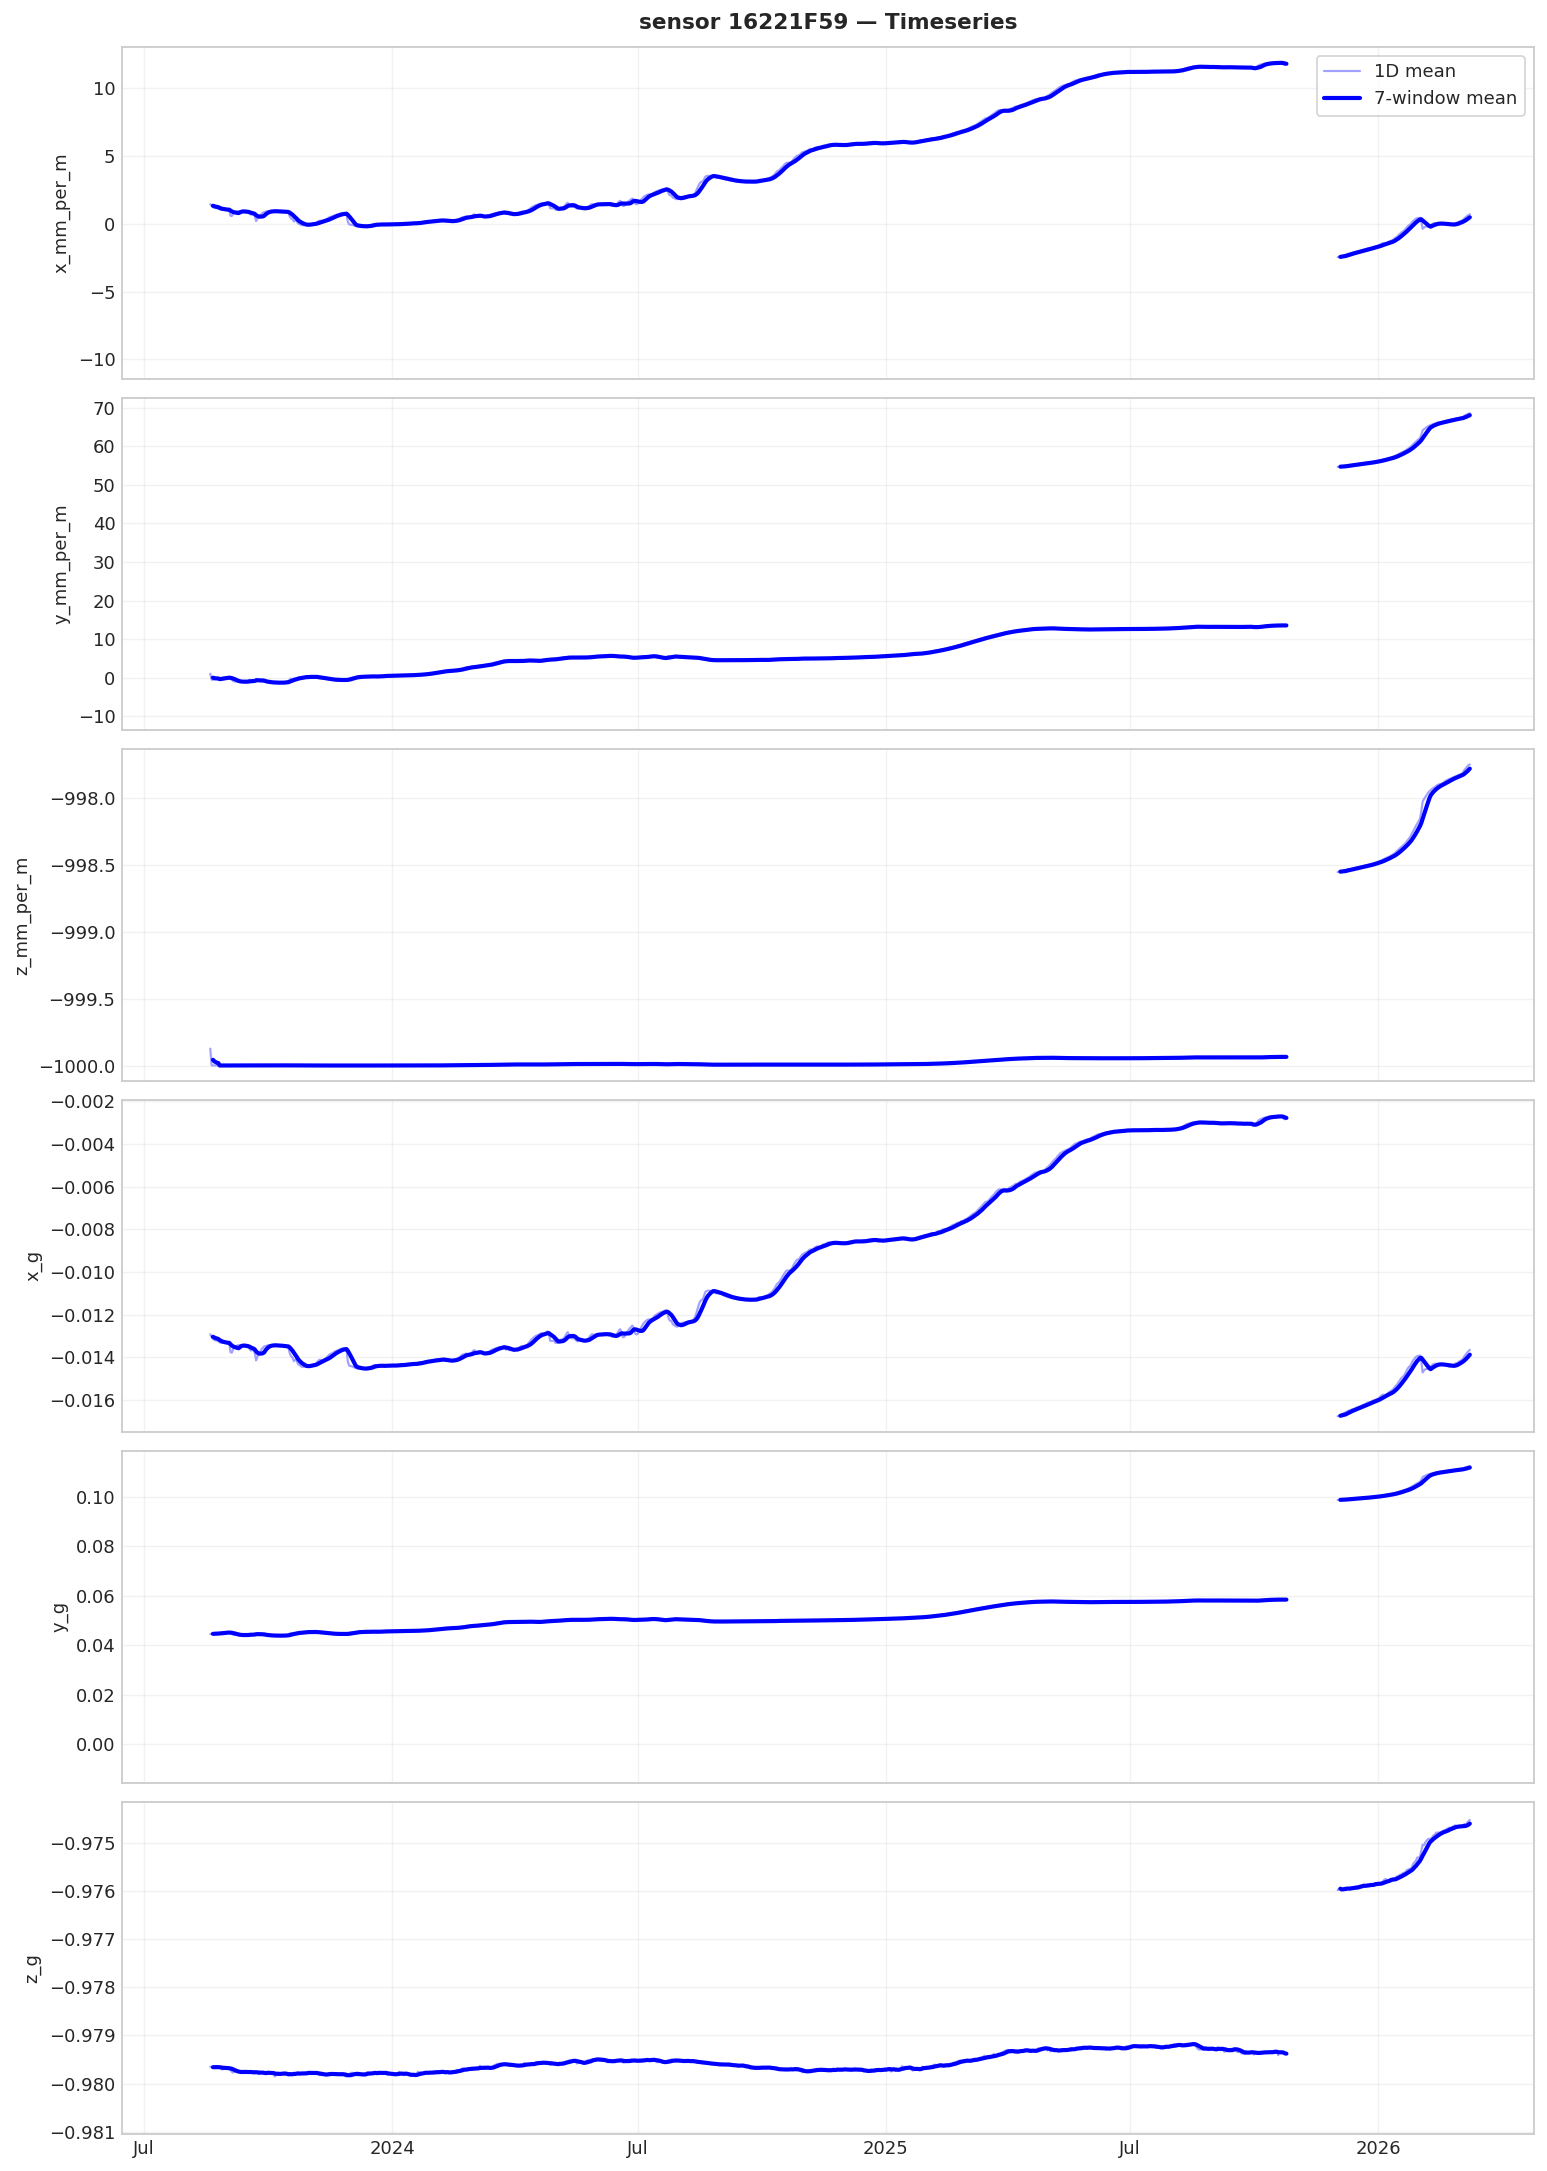

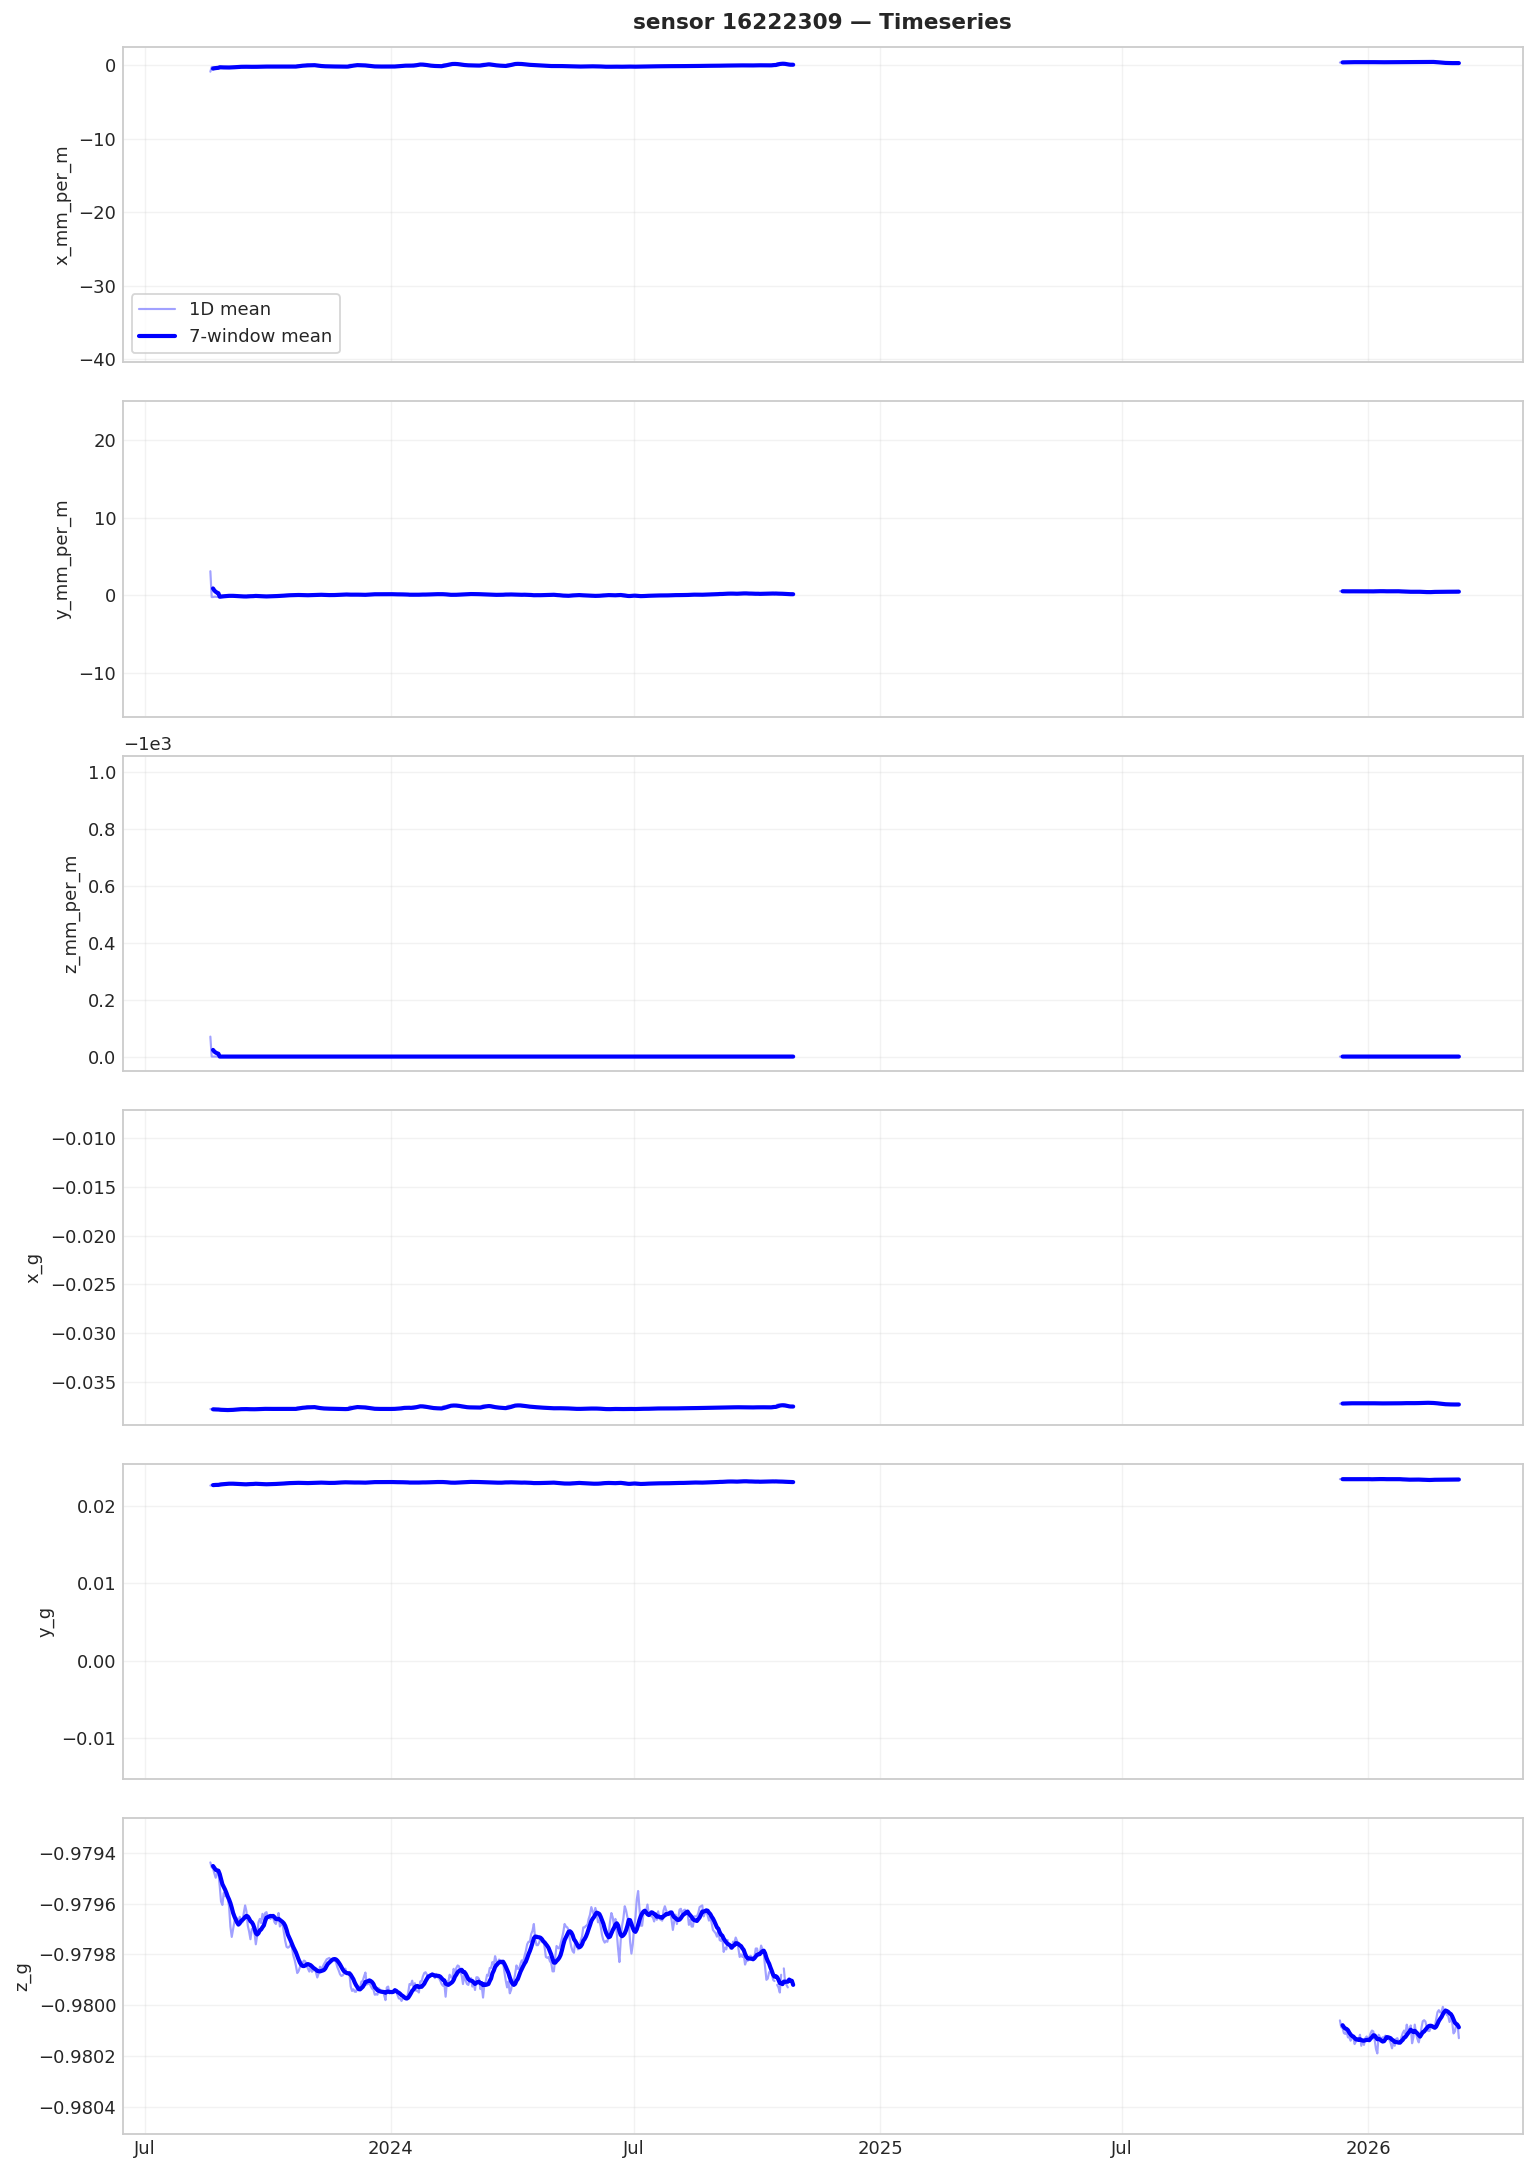

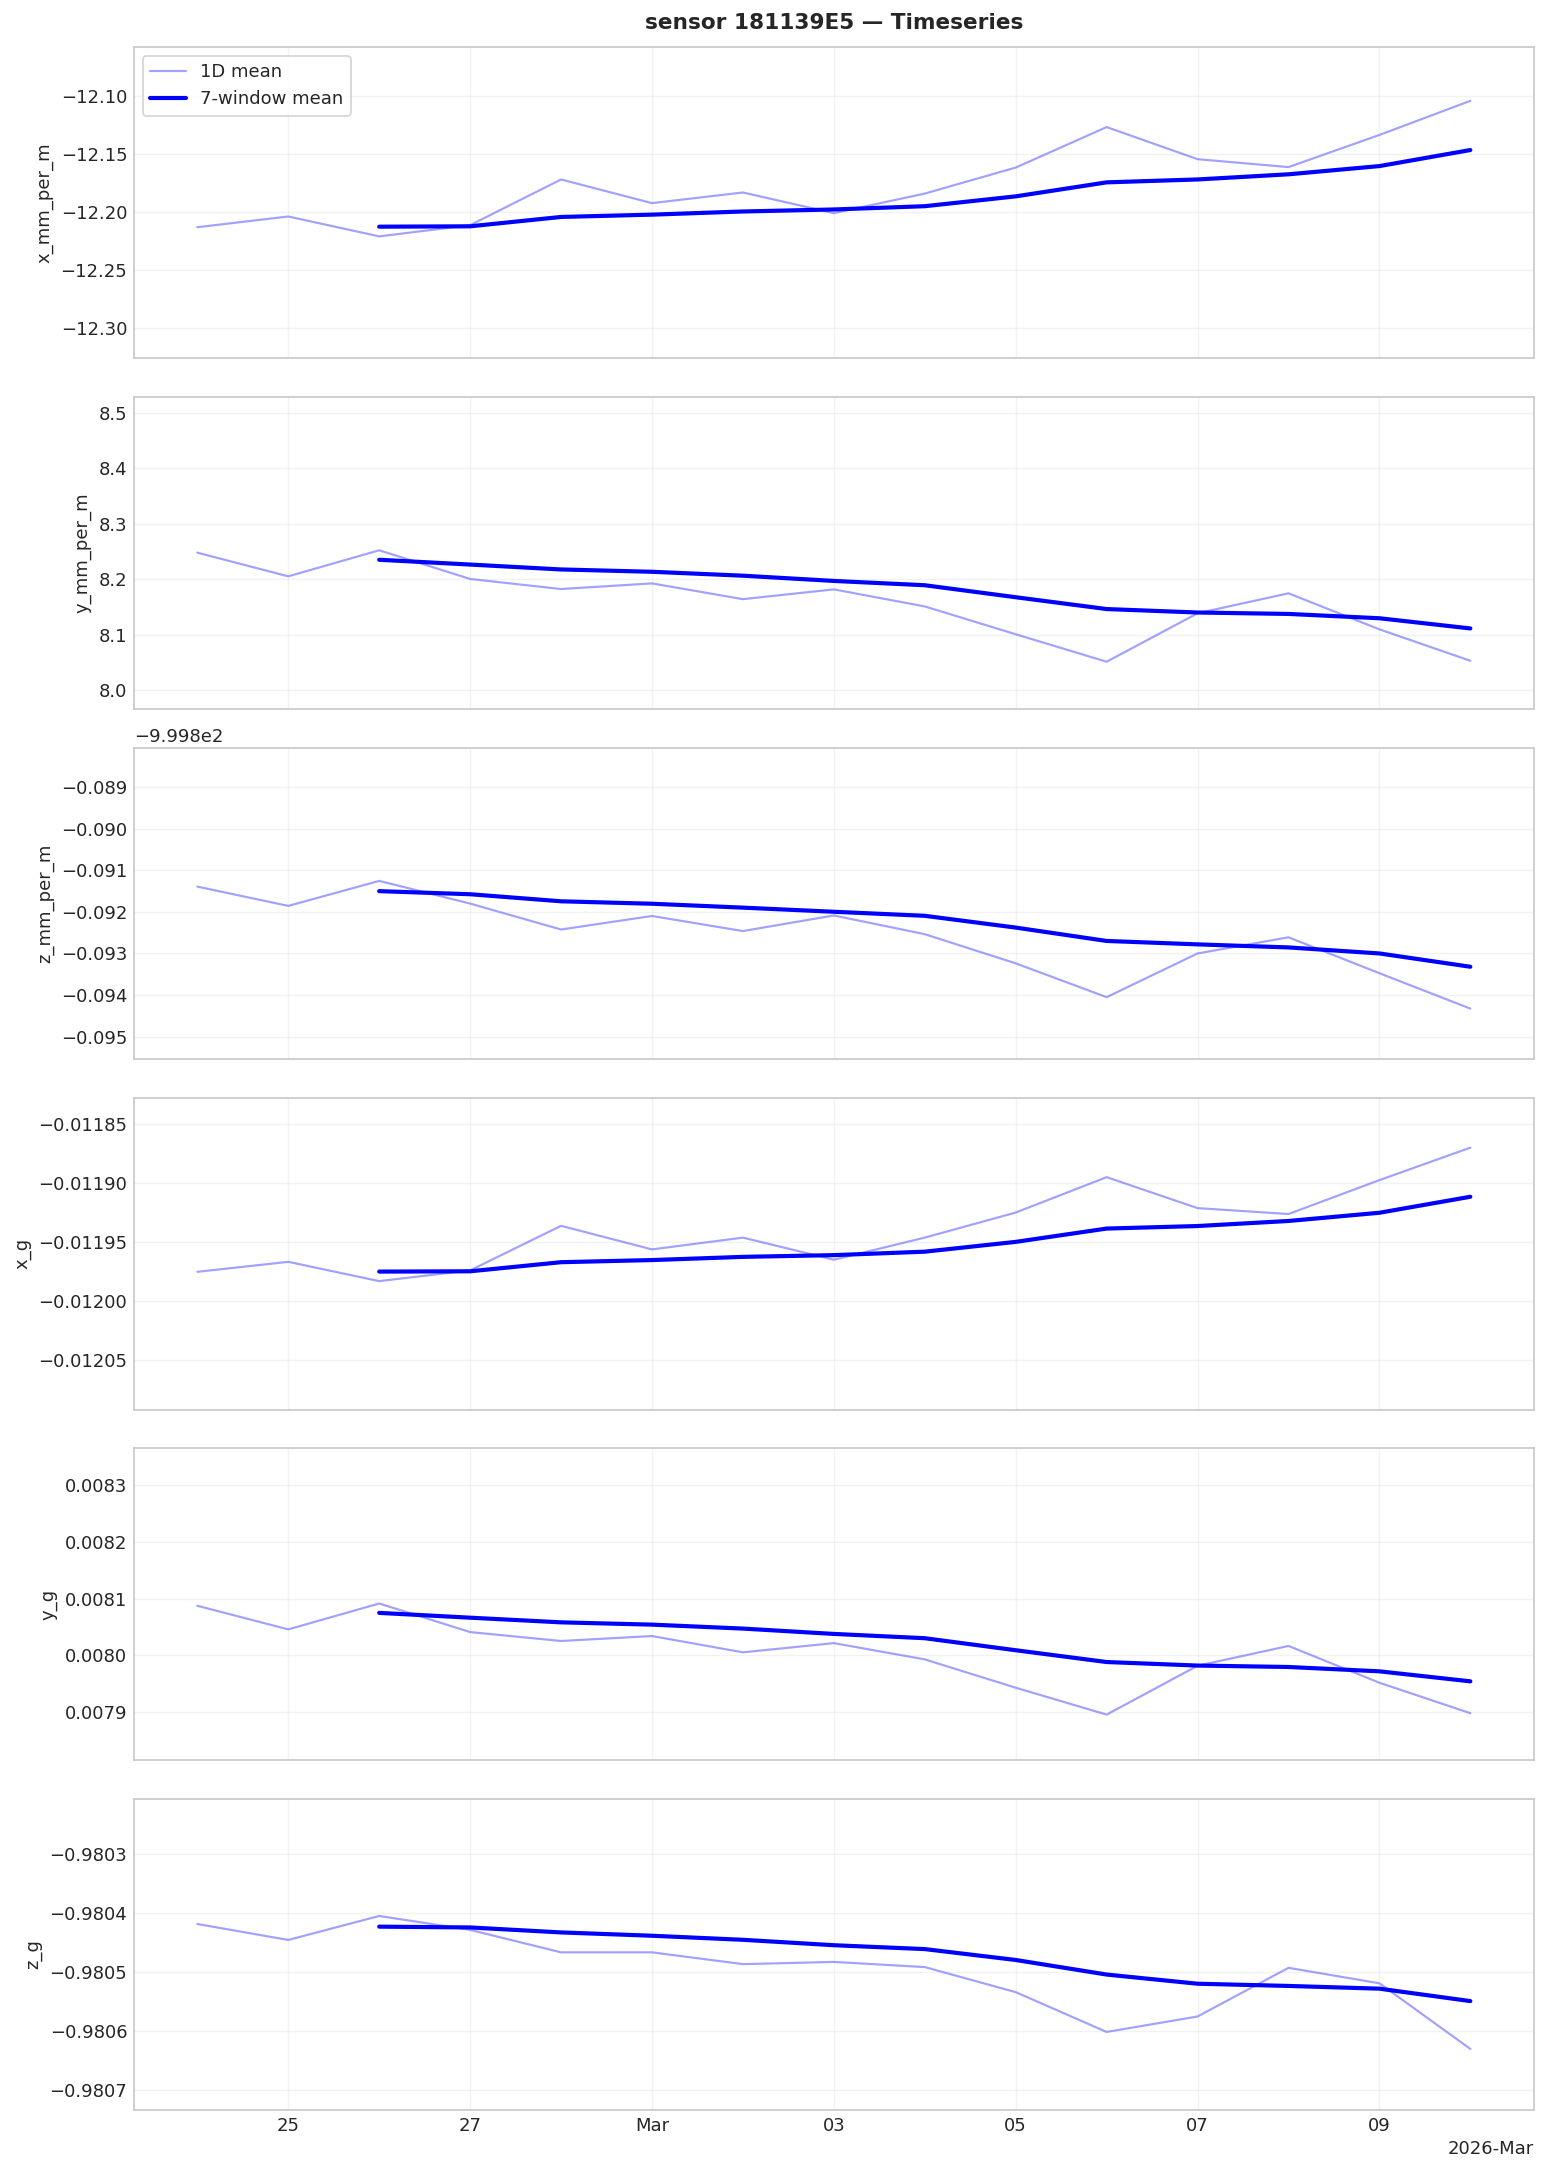

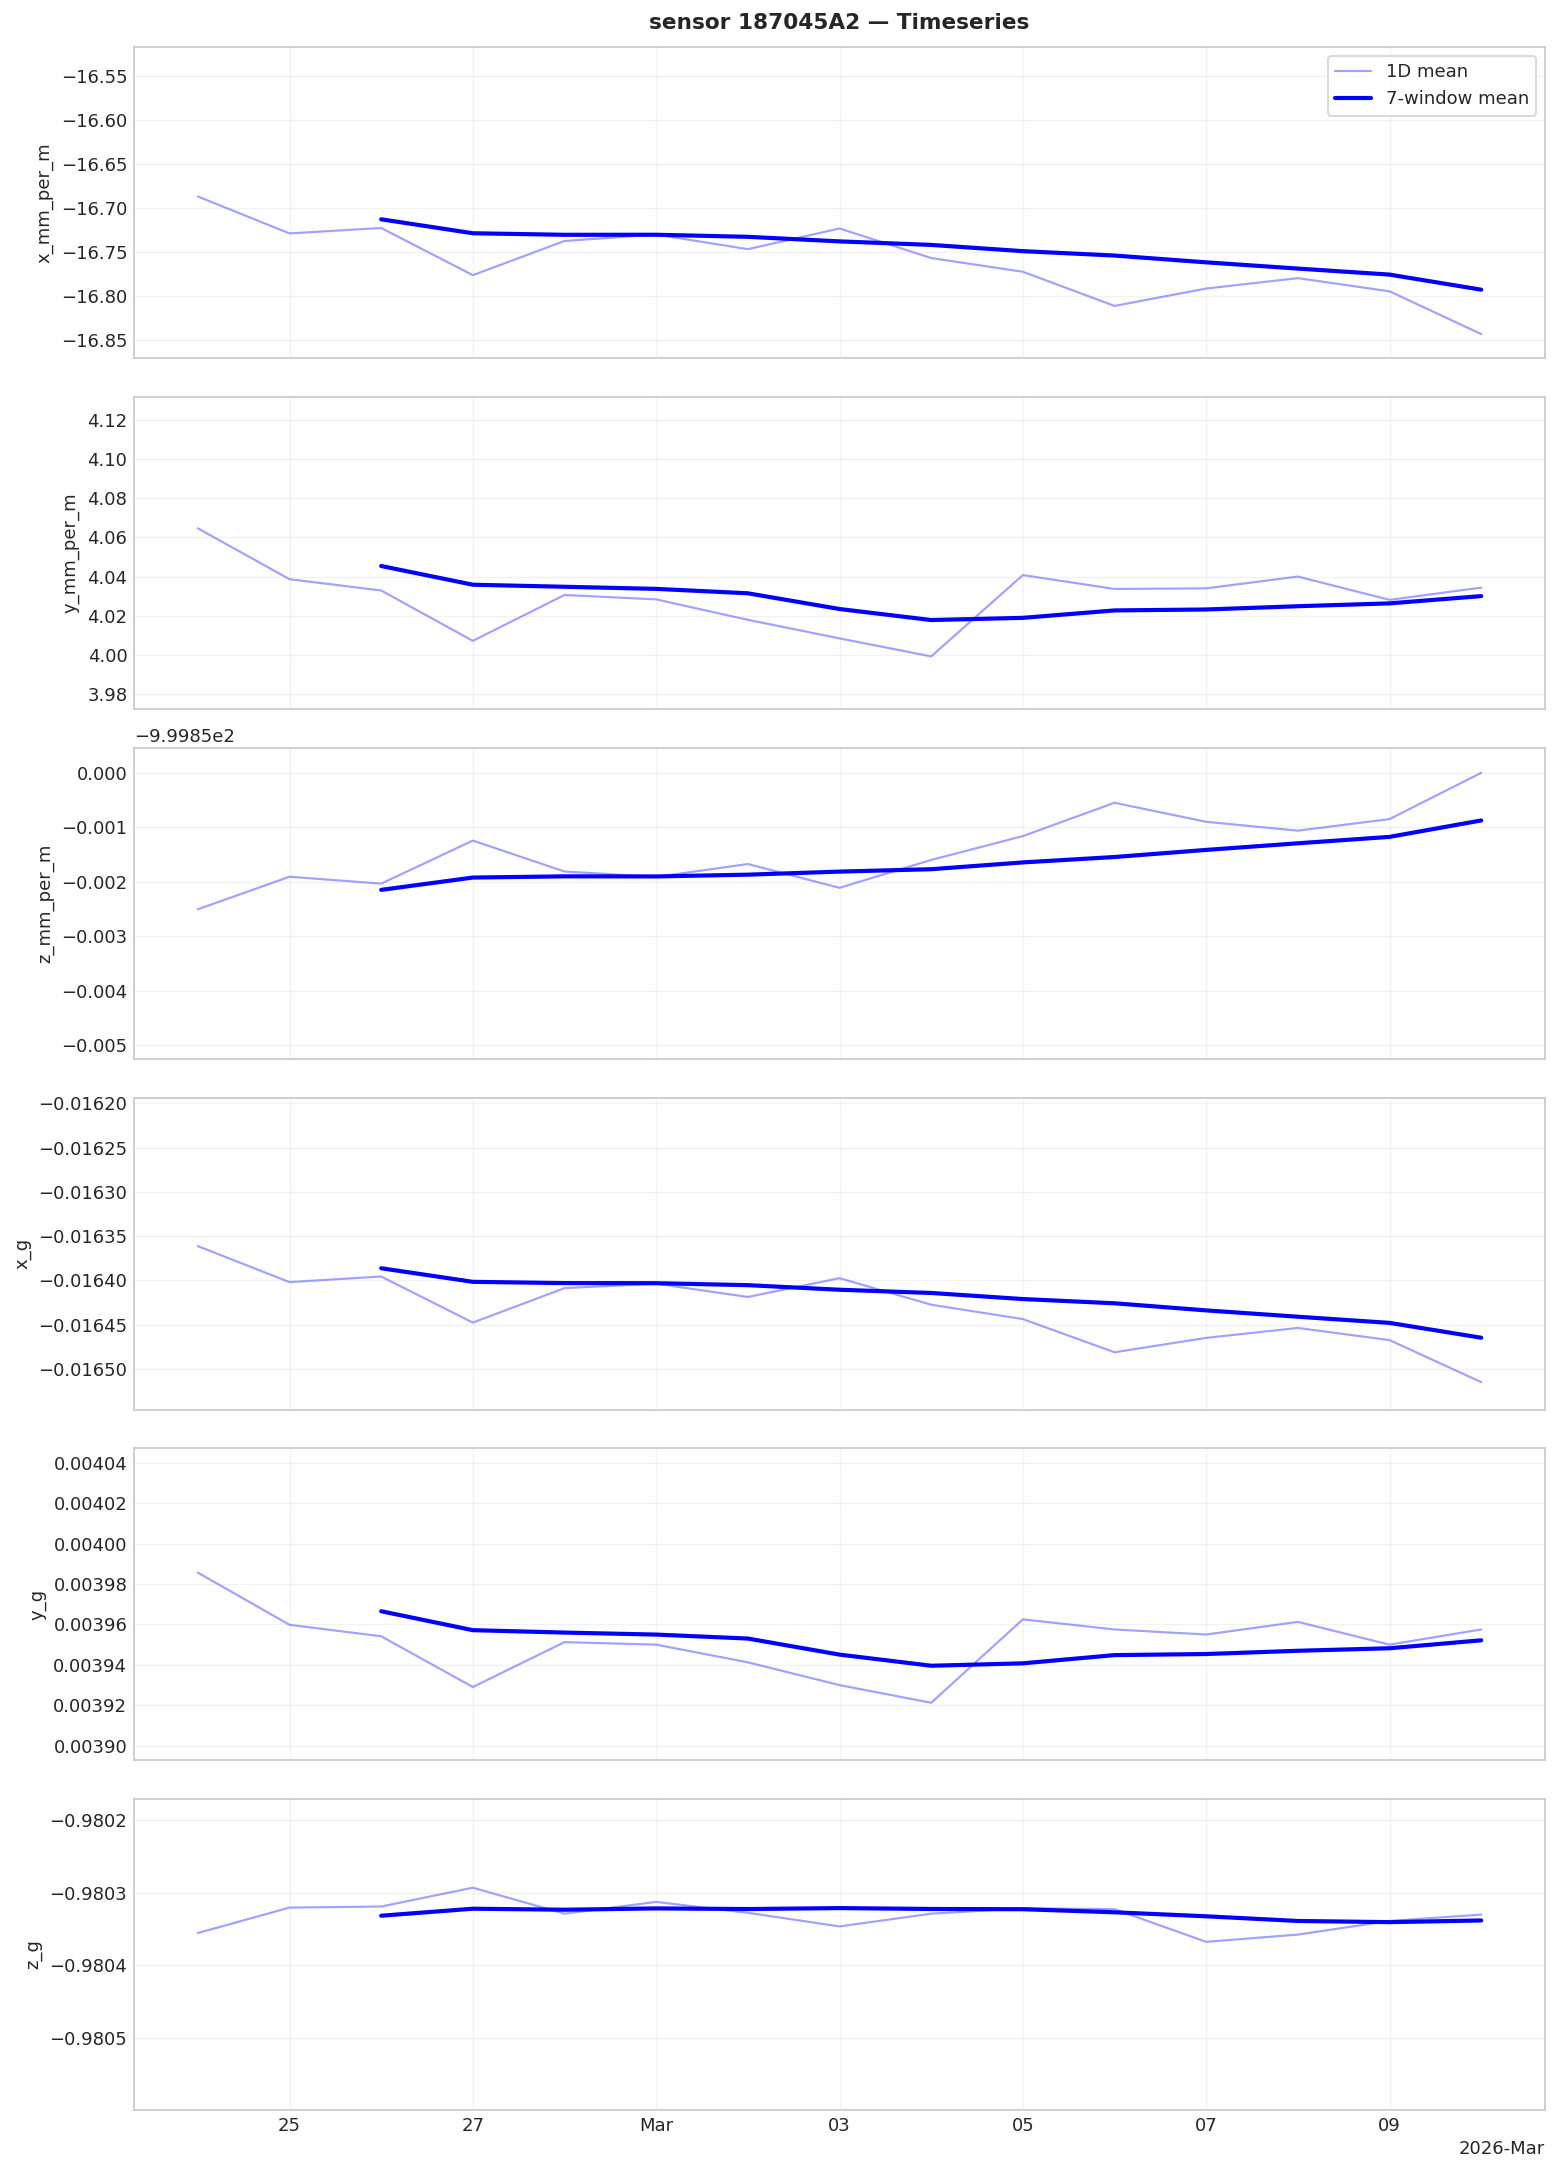


--- DISTRIBUTION PLOTS ---


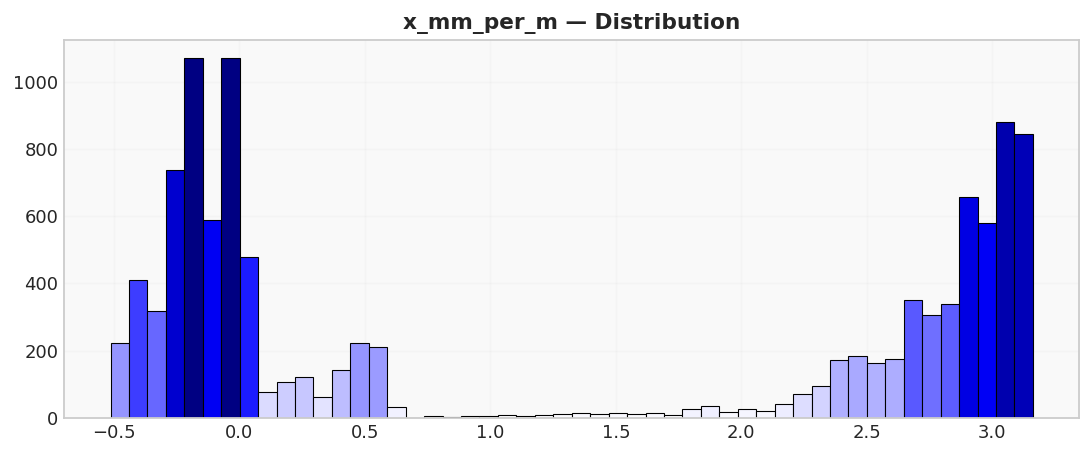

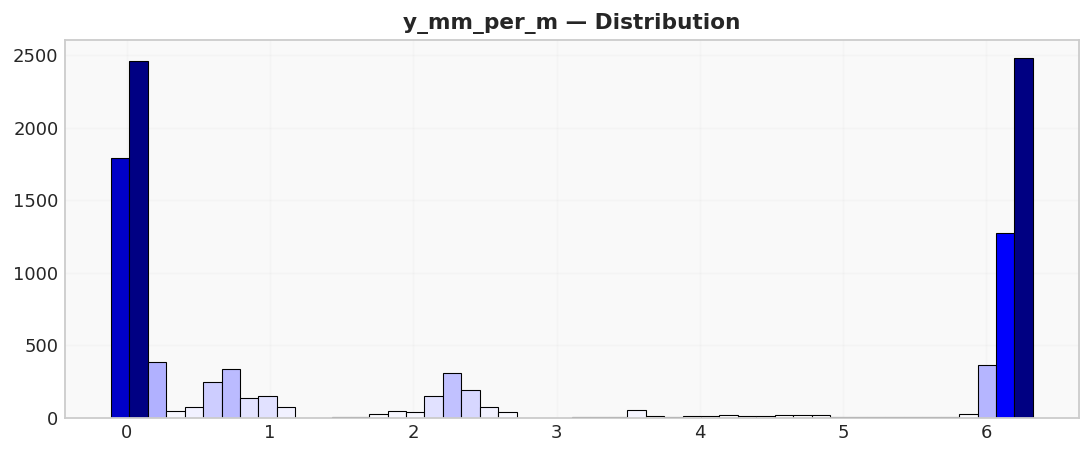

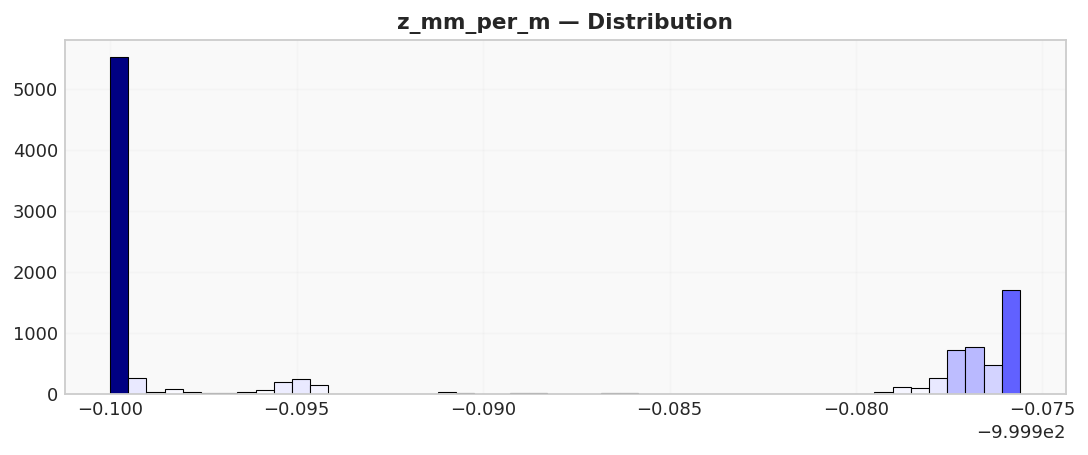

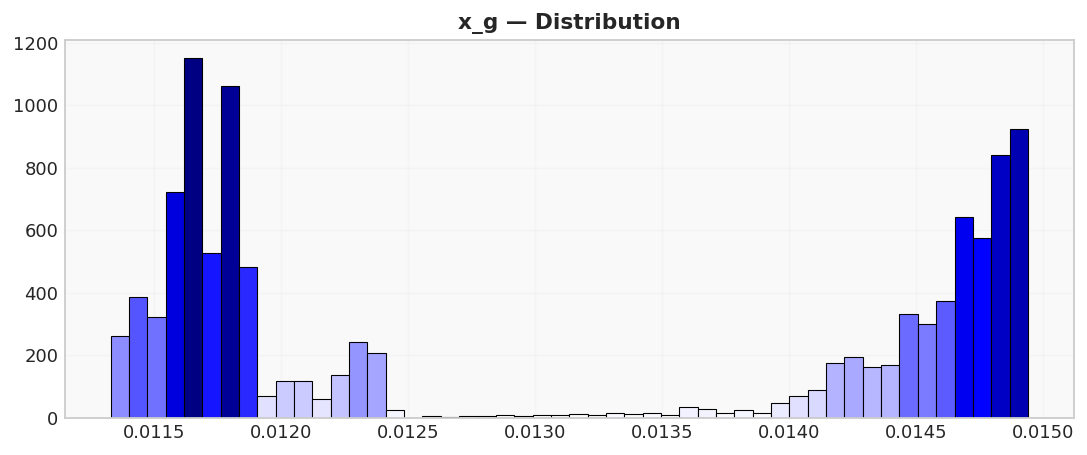

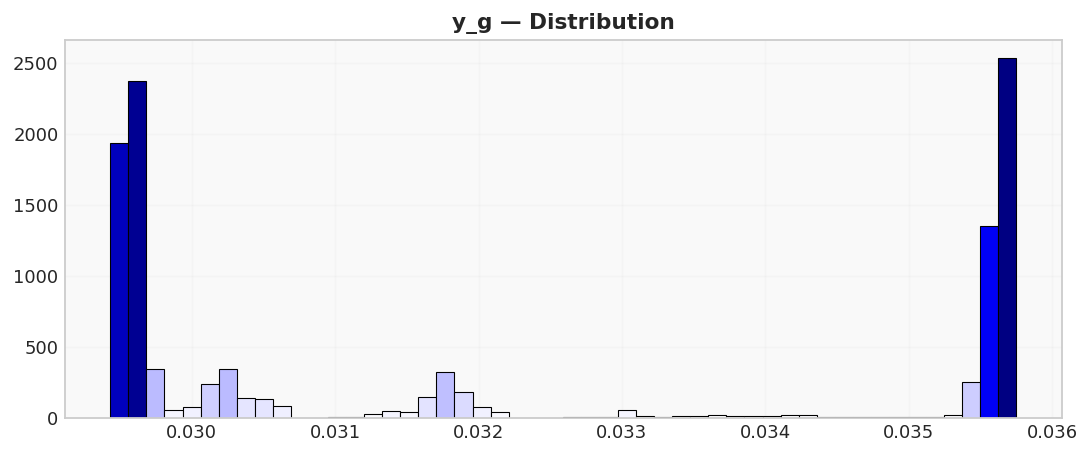

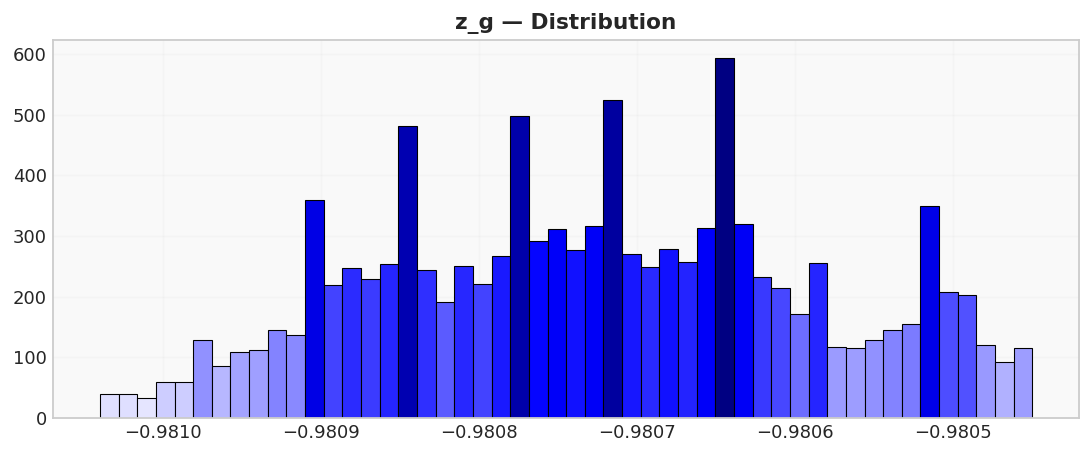


--- CORRELATION MATRIX (variables) ---


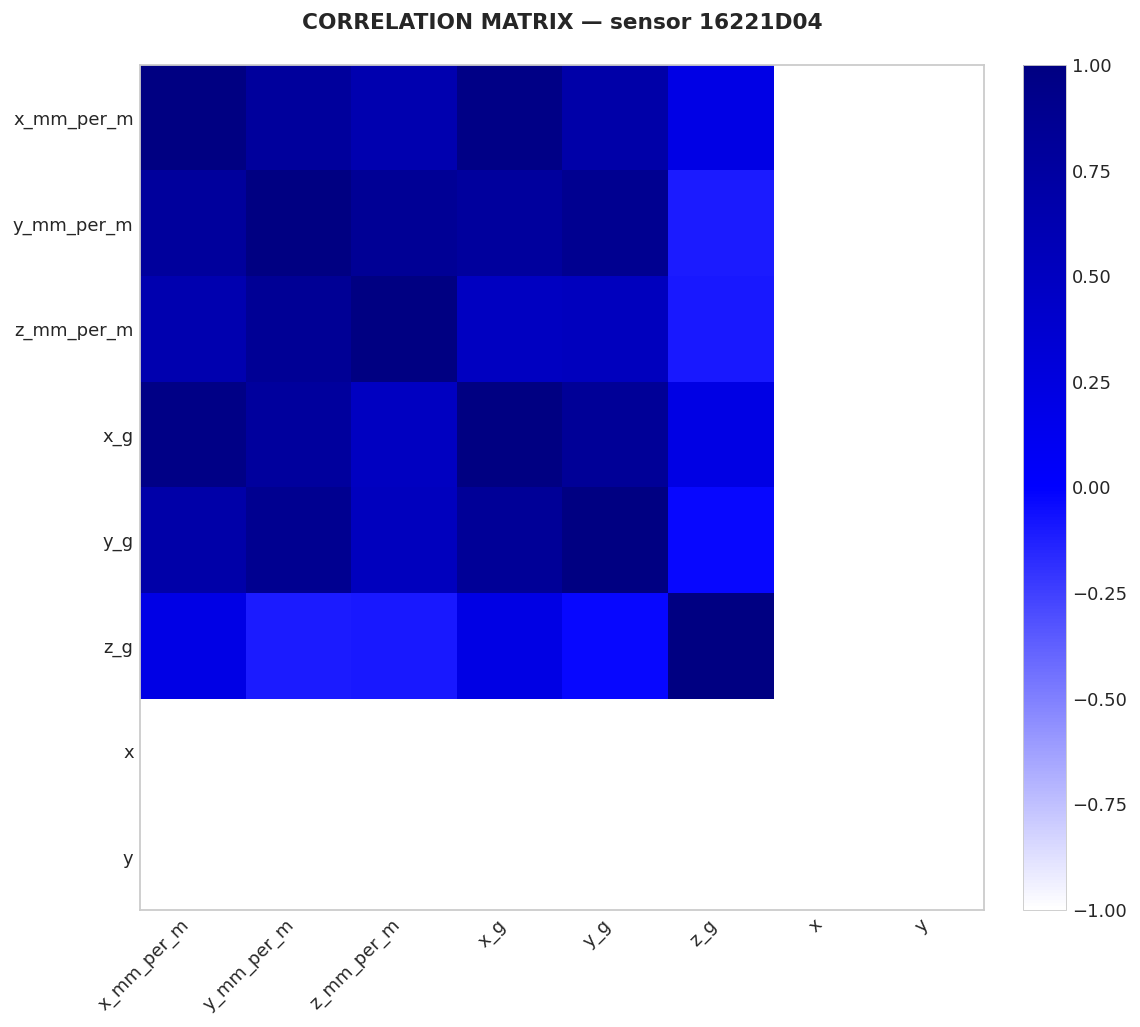


--- AVAILABILITY ---


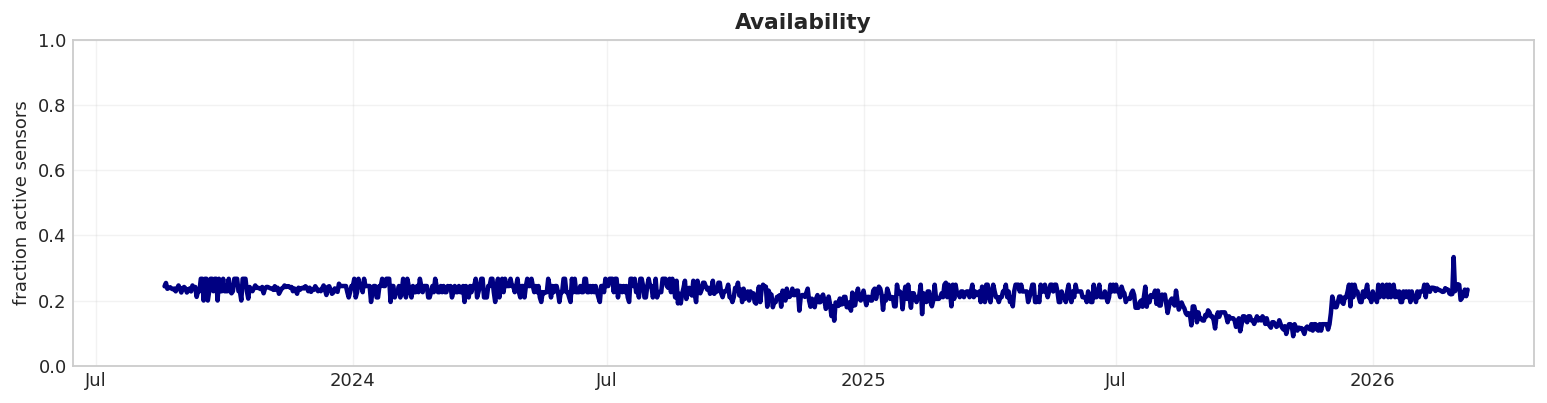


--- SENSOR-SENSOR CORRELATION ---


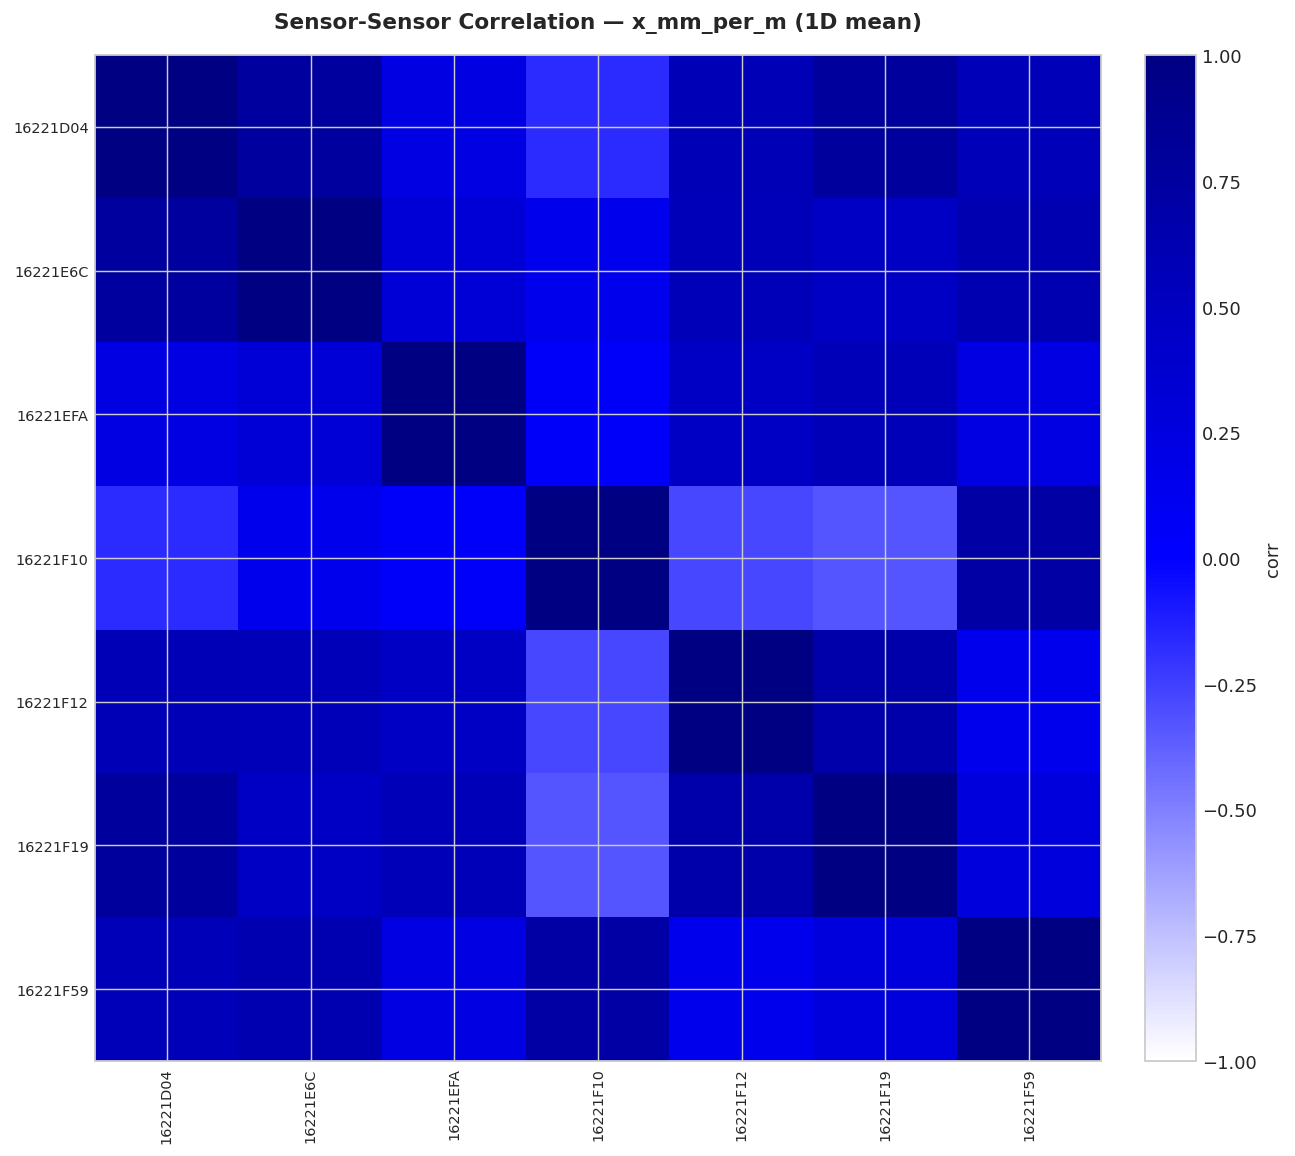


--- AVAILABILITY HEATMAP ---


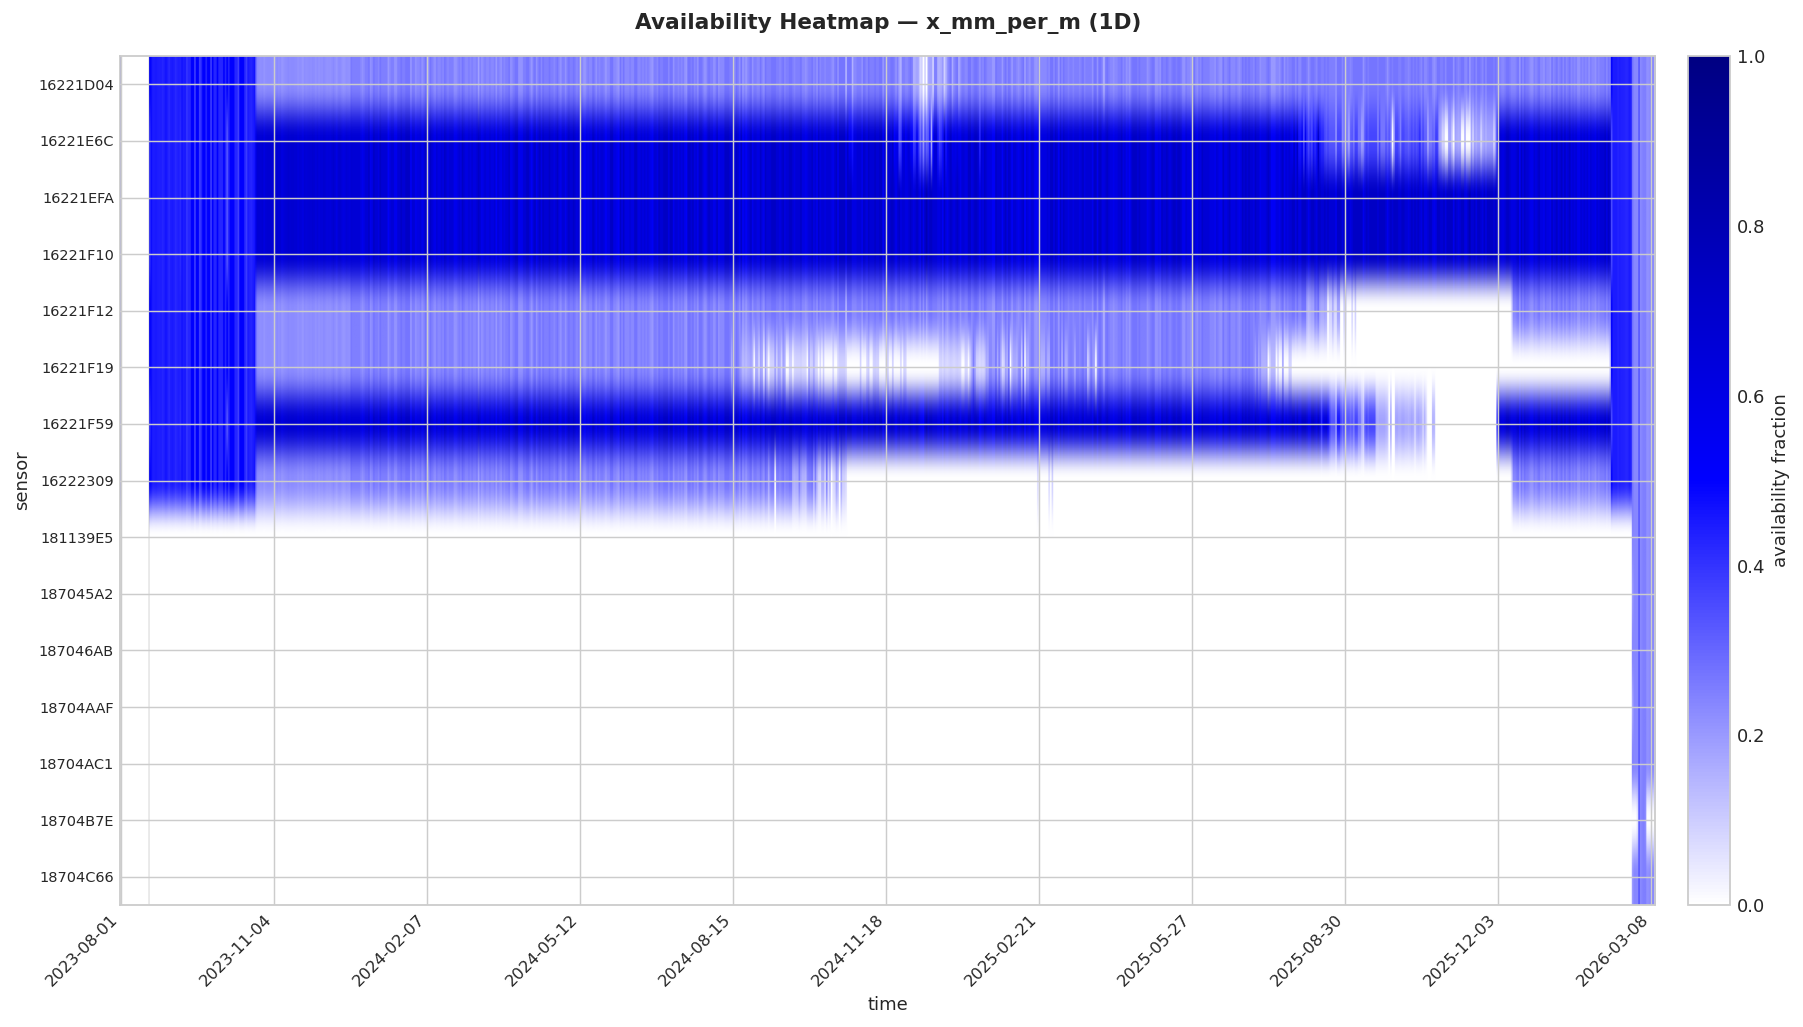


--- OVERLAY SENSORS ---


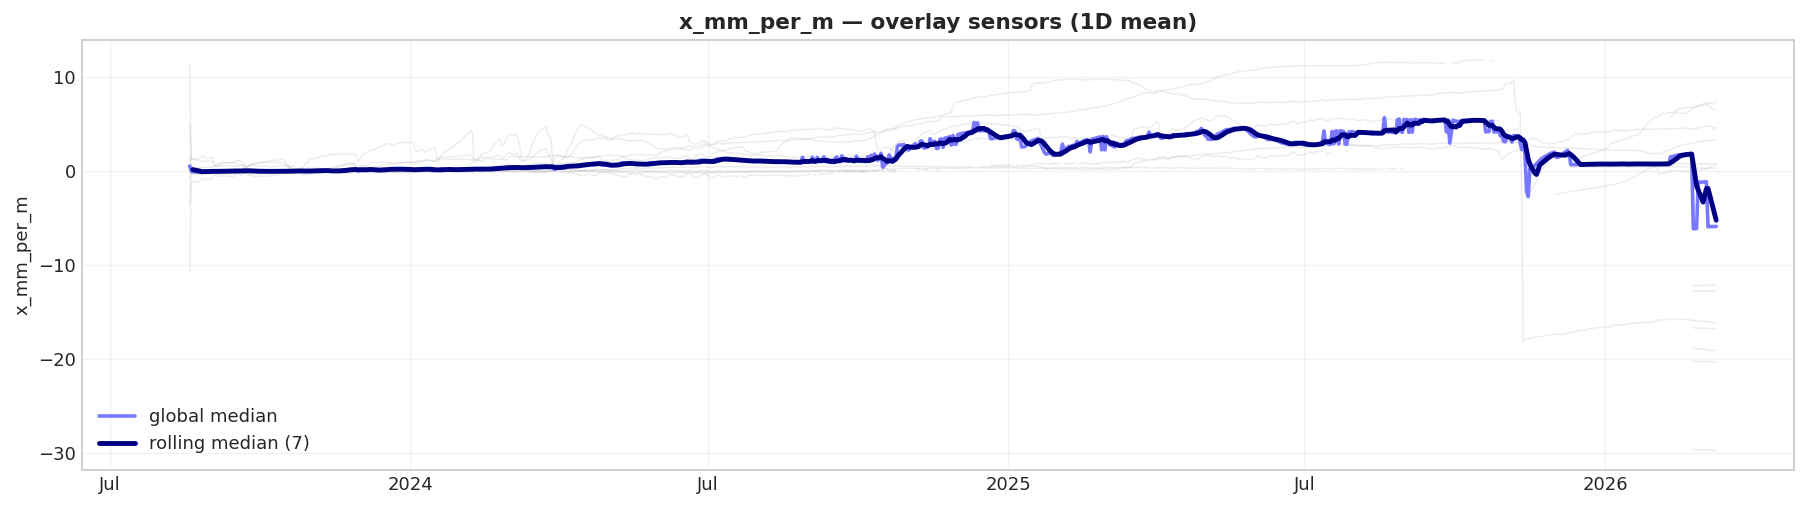

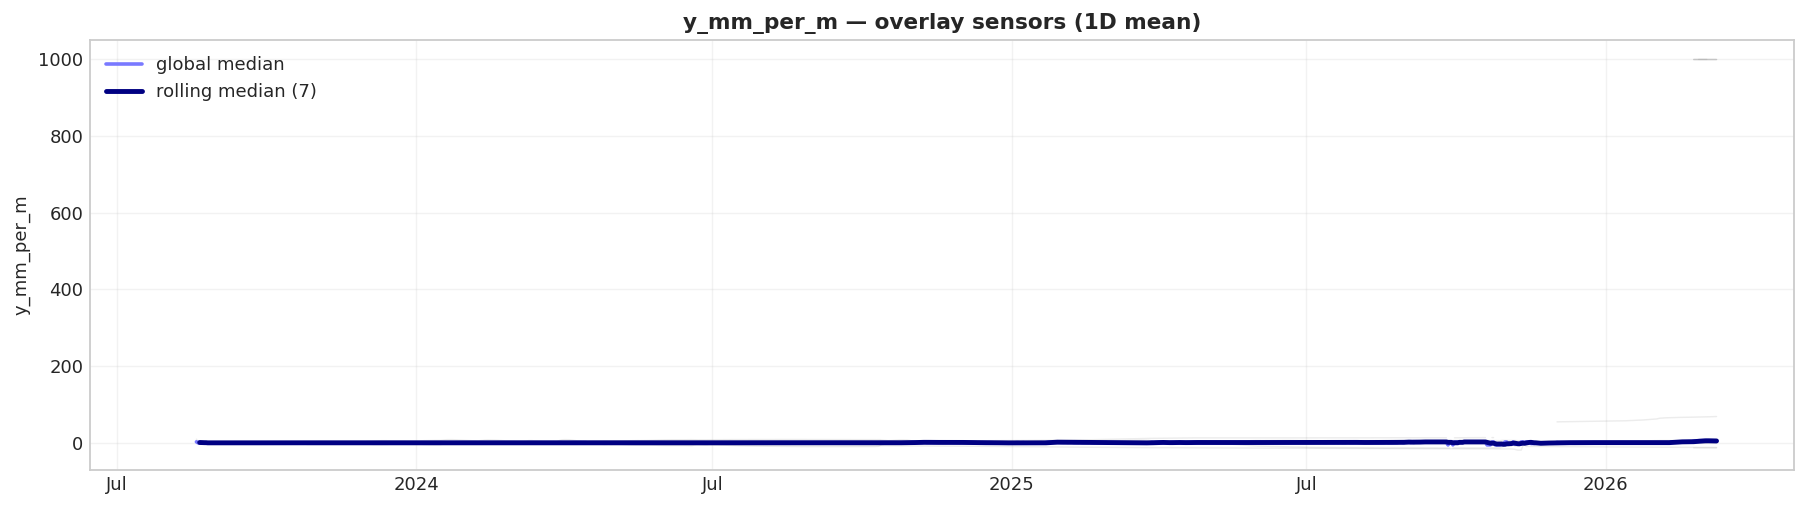

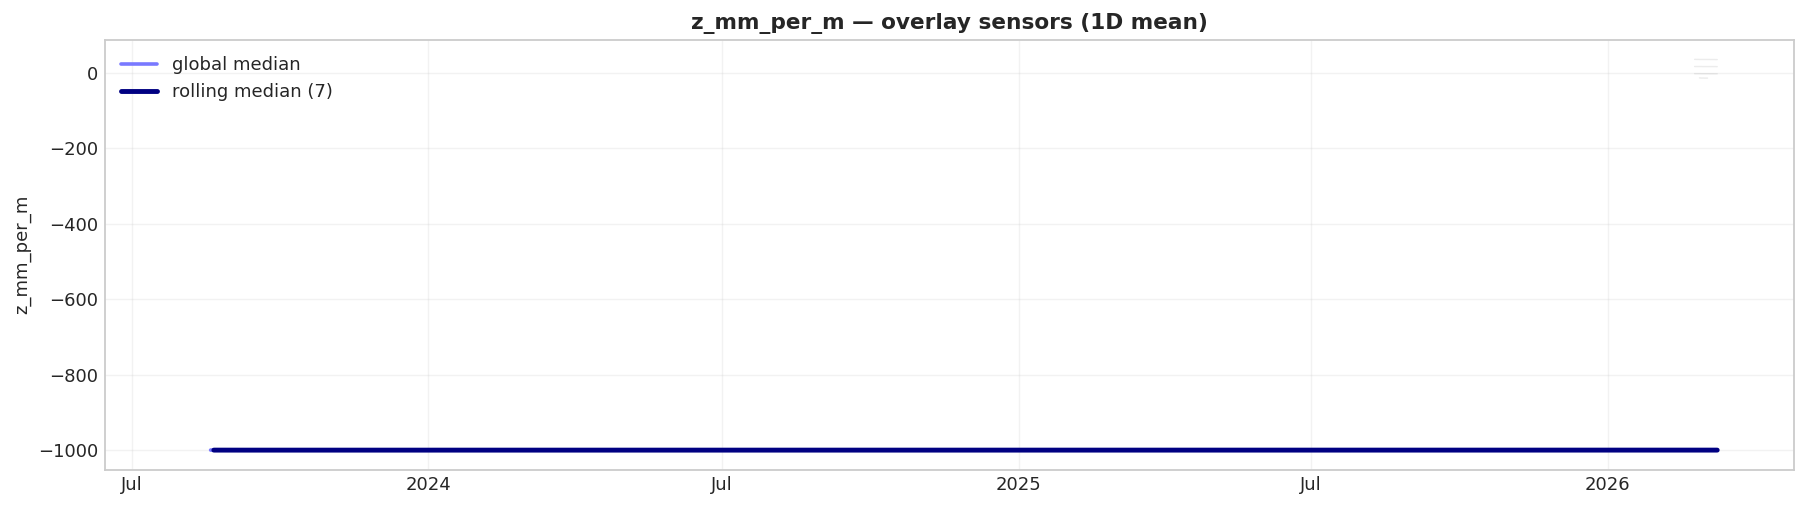

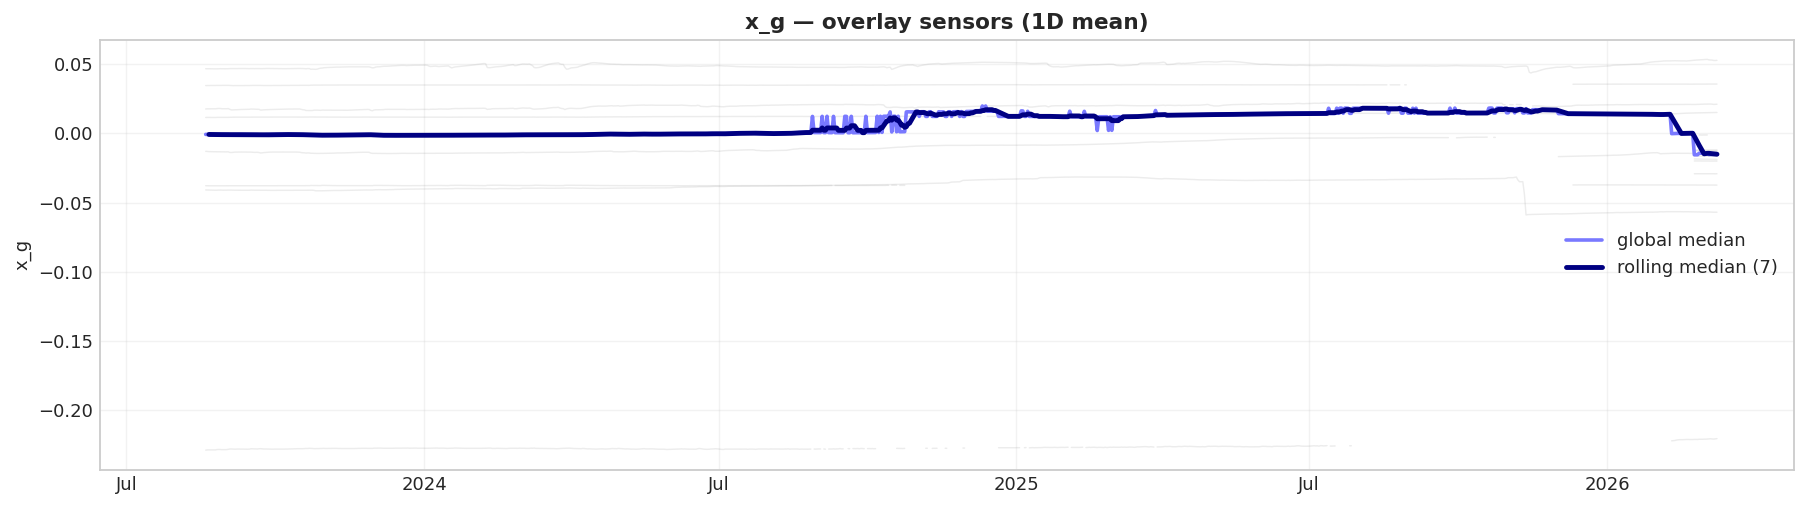

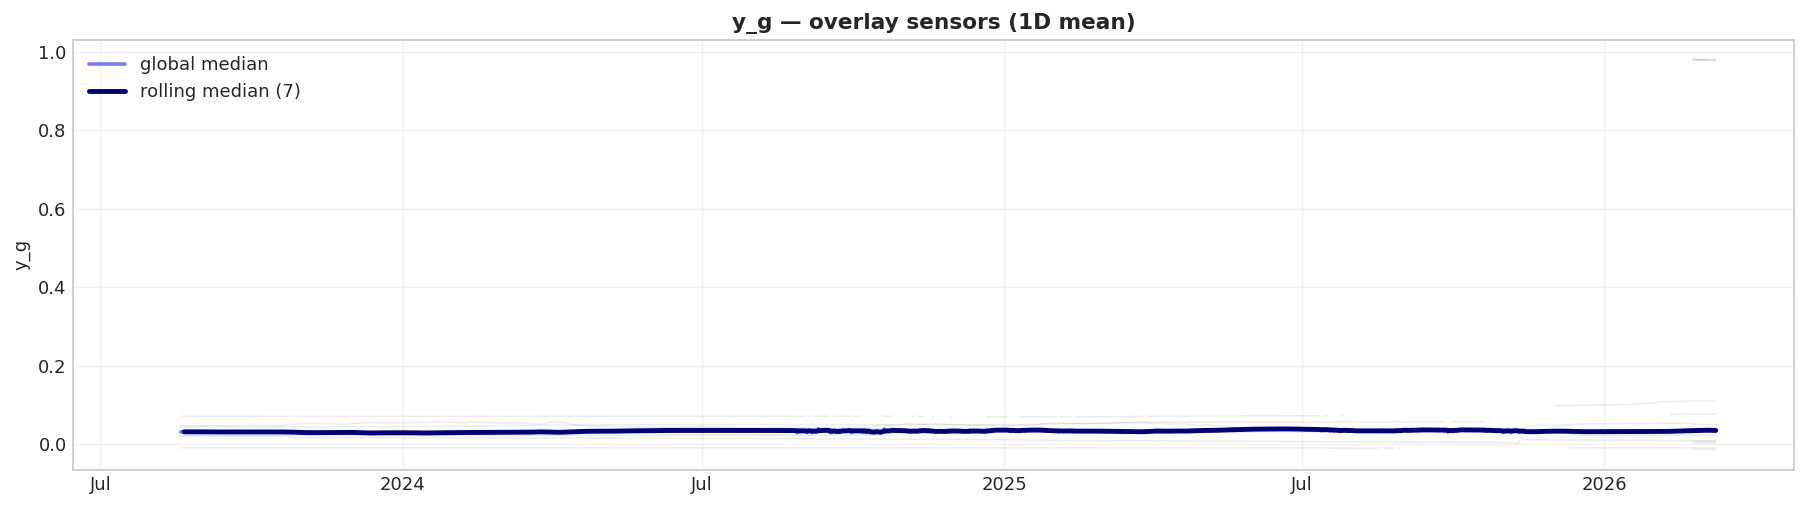

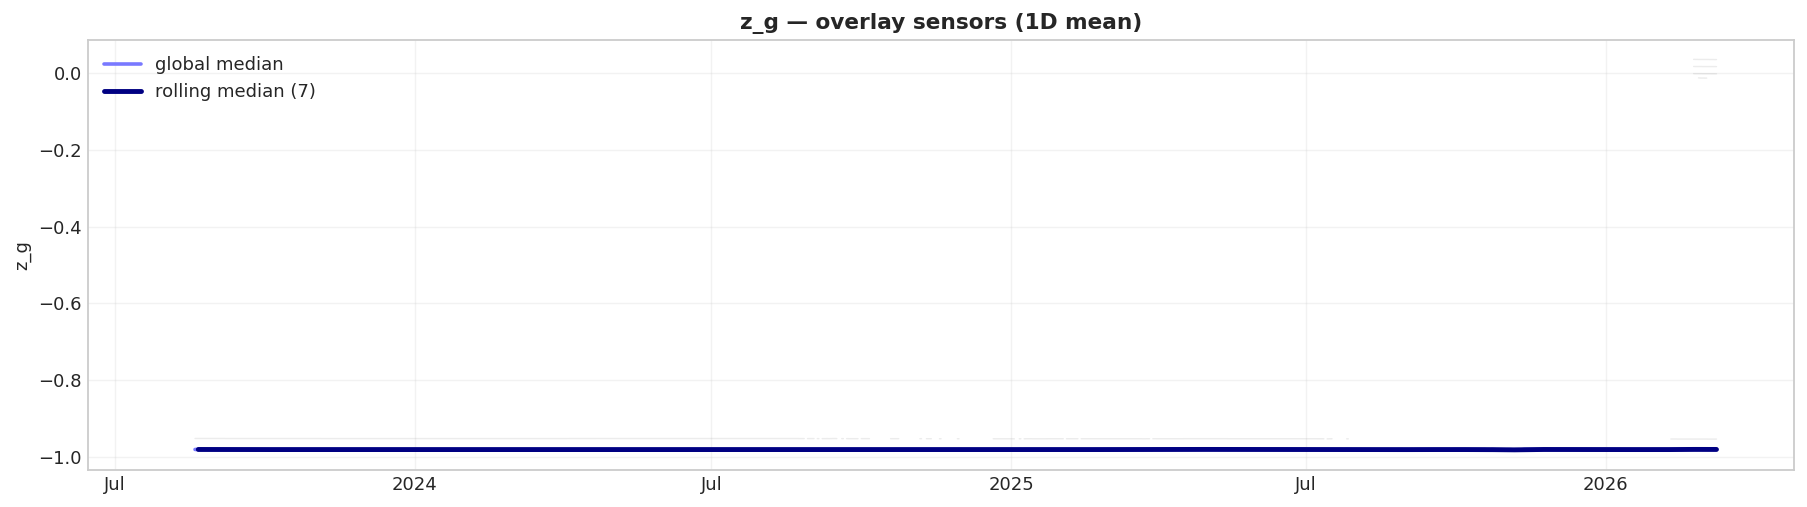


--- BOXPLOT BY SENSOR ---


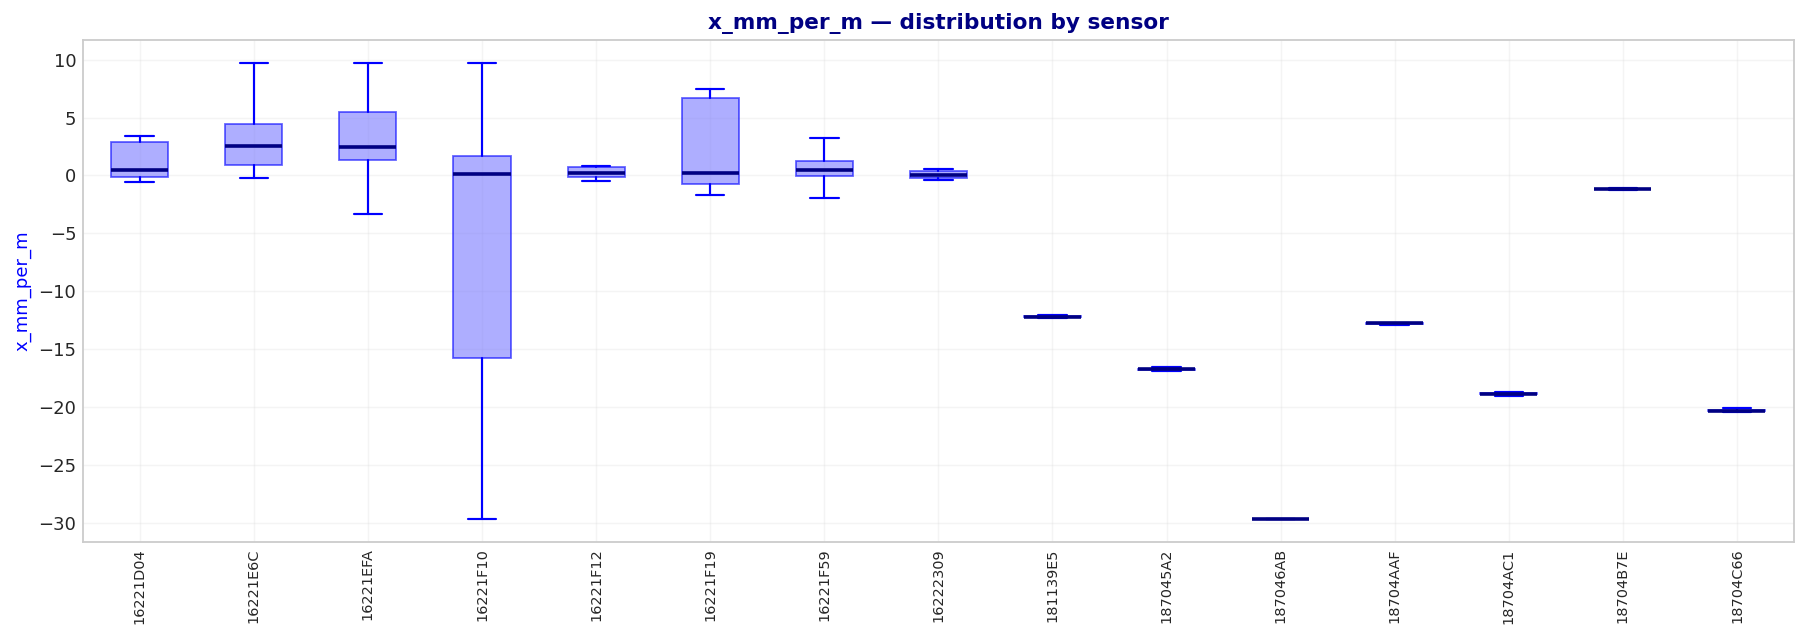

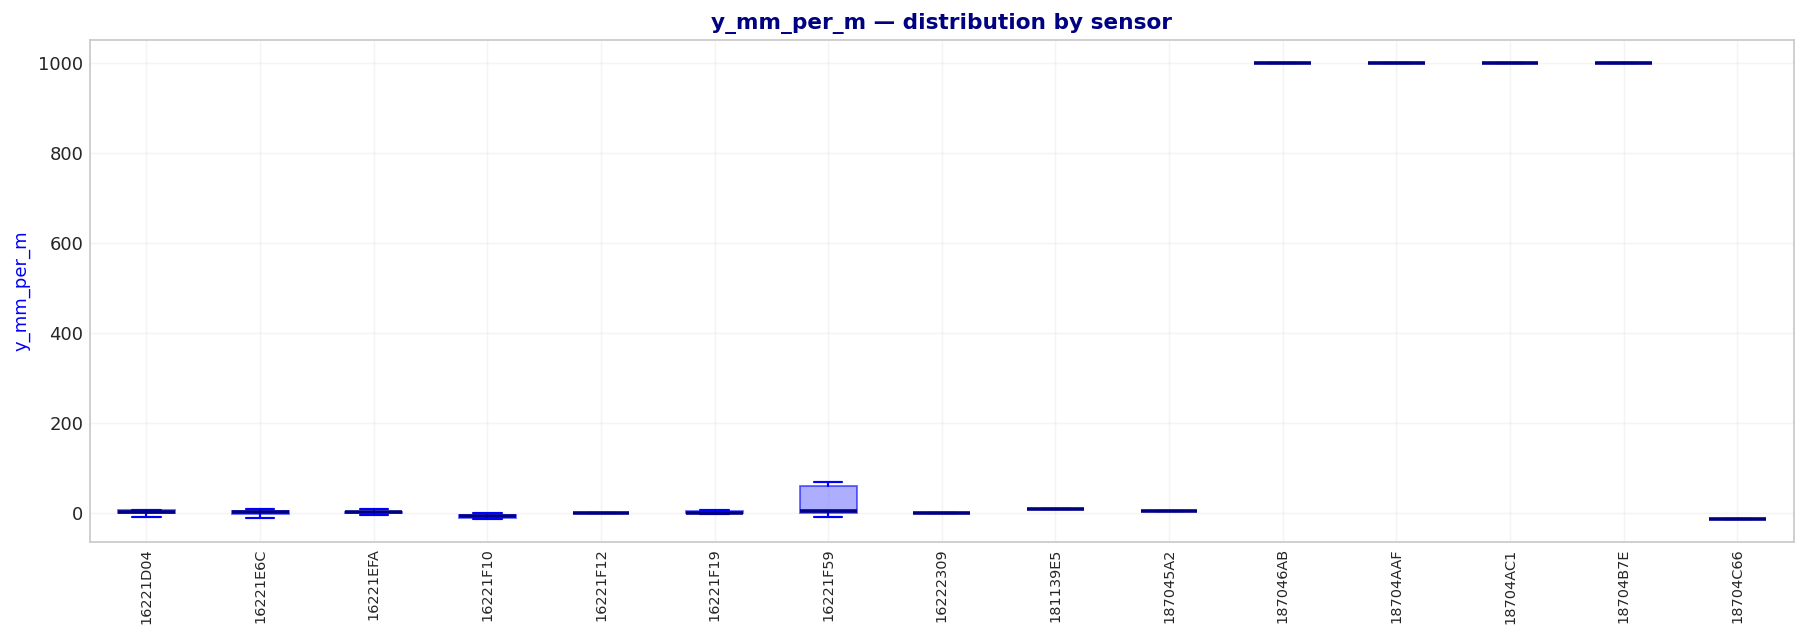

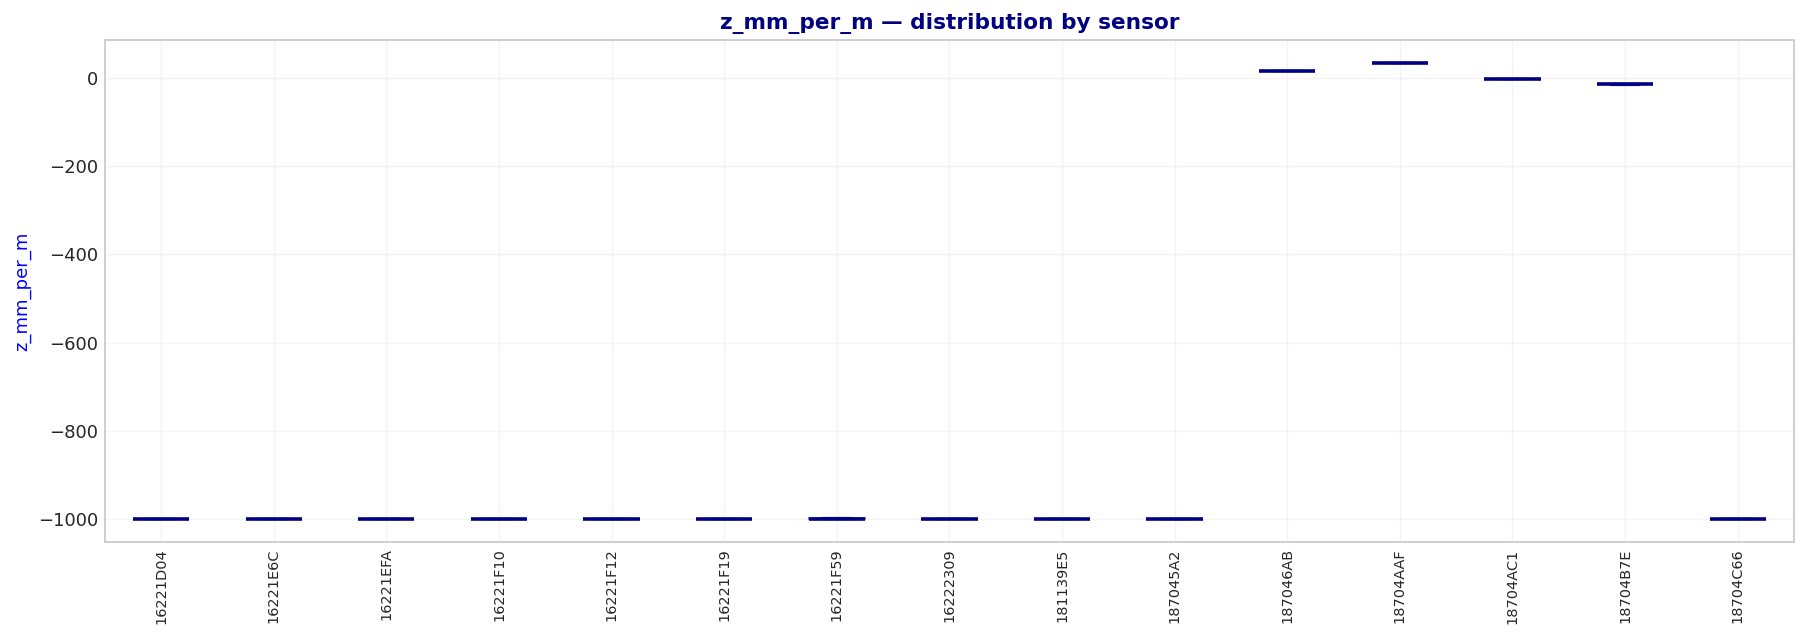

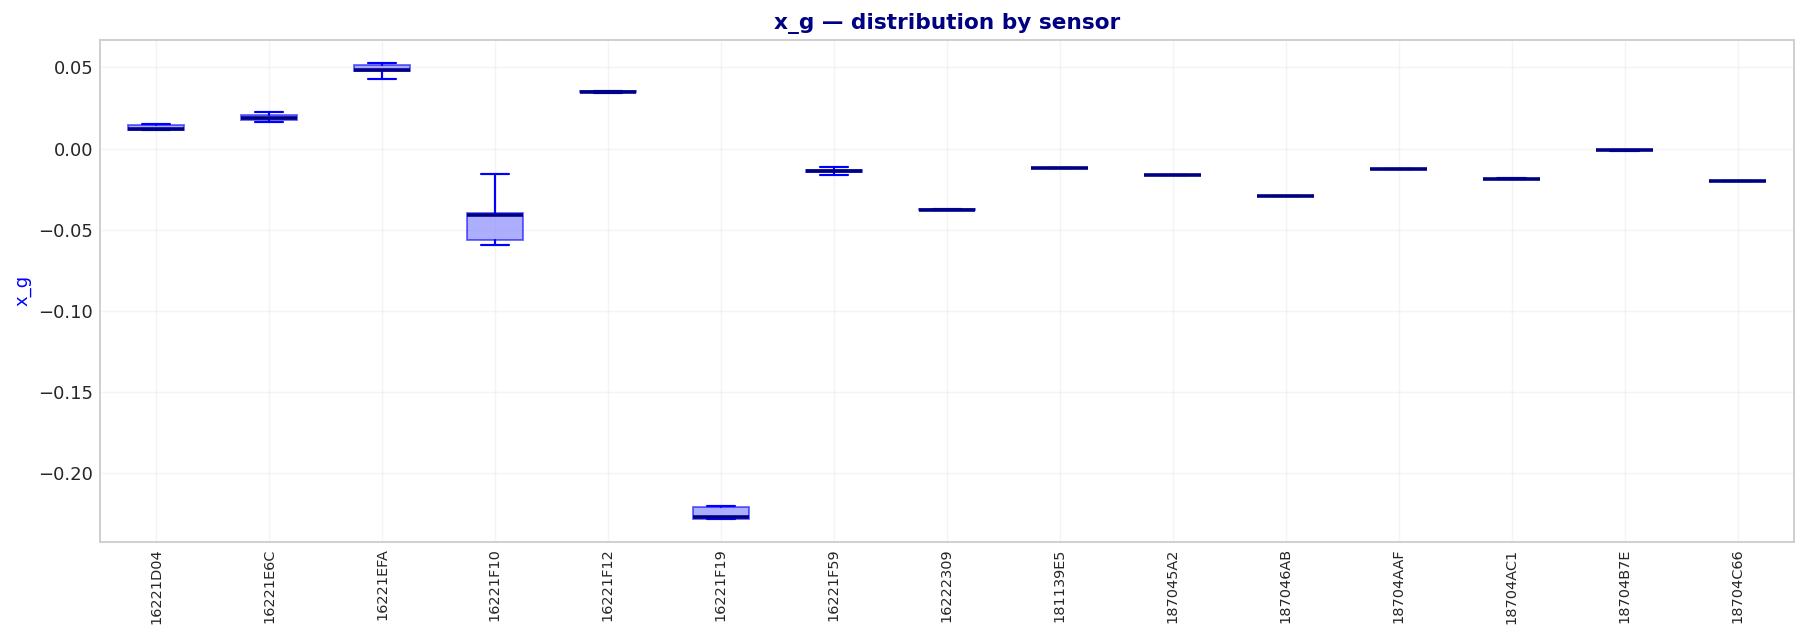

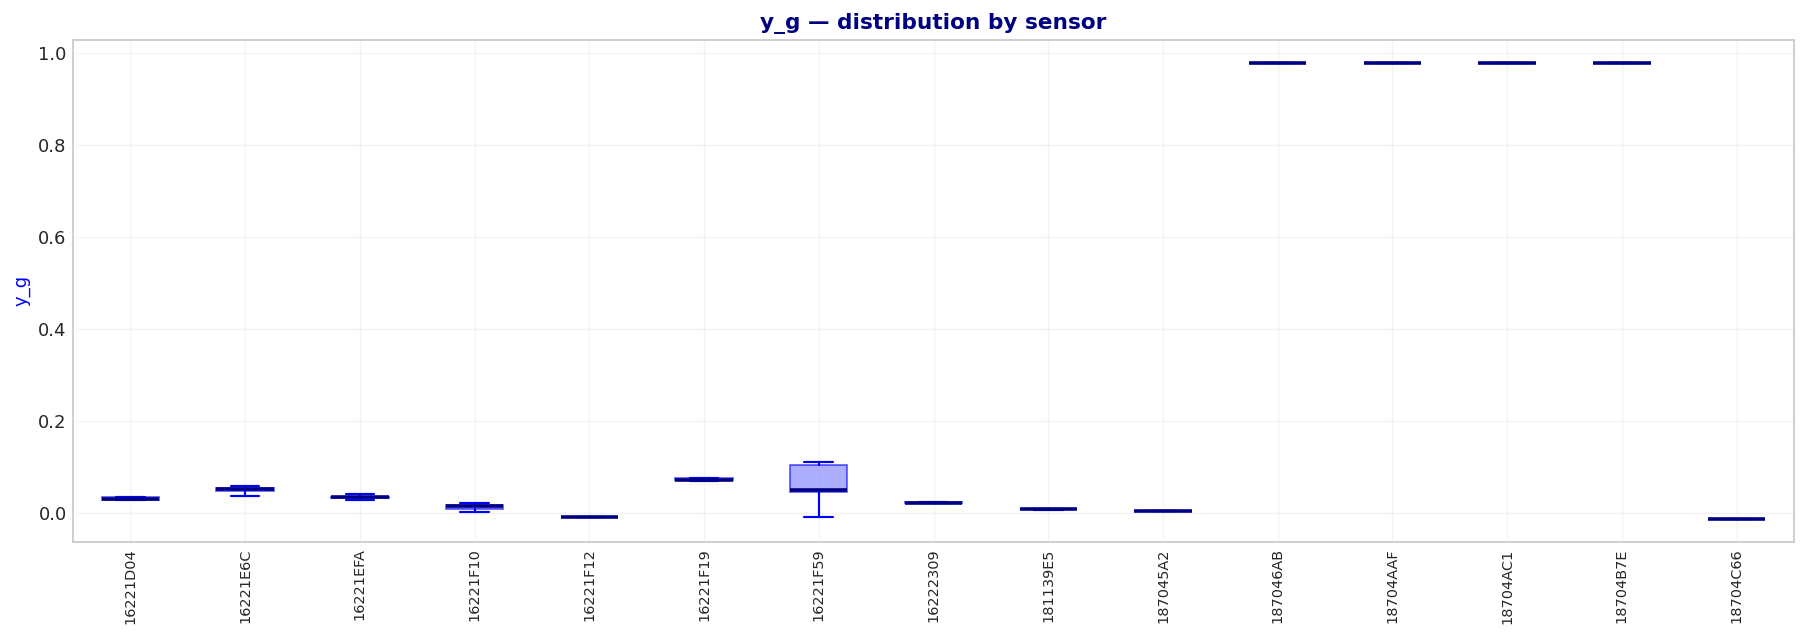

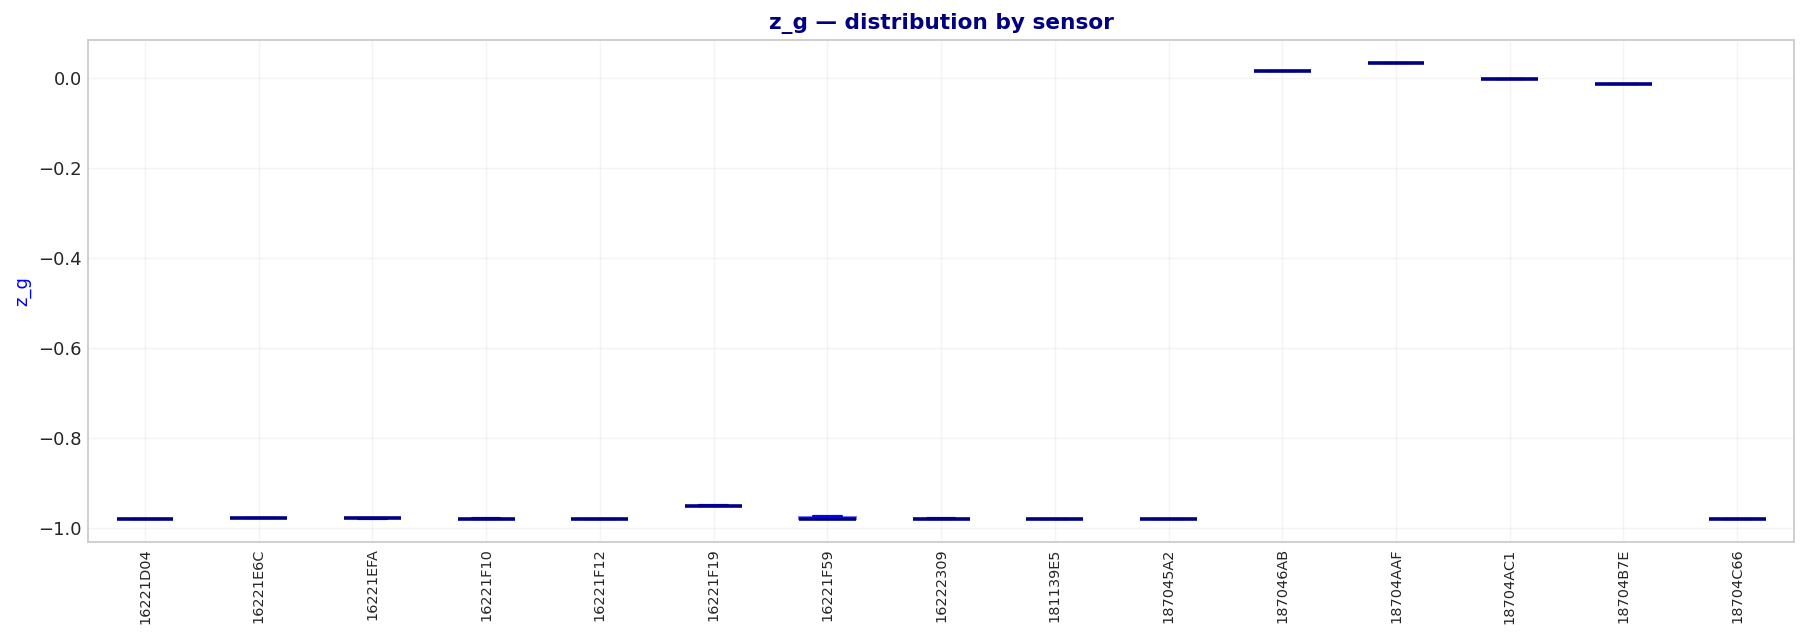


RUNNING PLOTS FOR: WEATHER STATION

--- TIMESERIES PLOTS ---


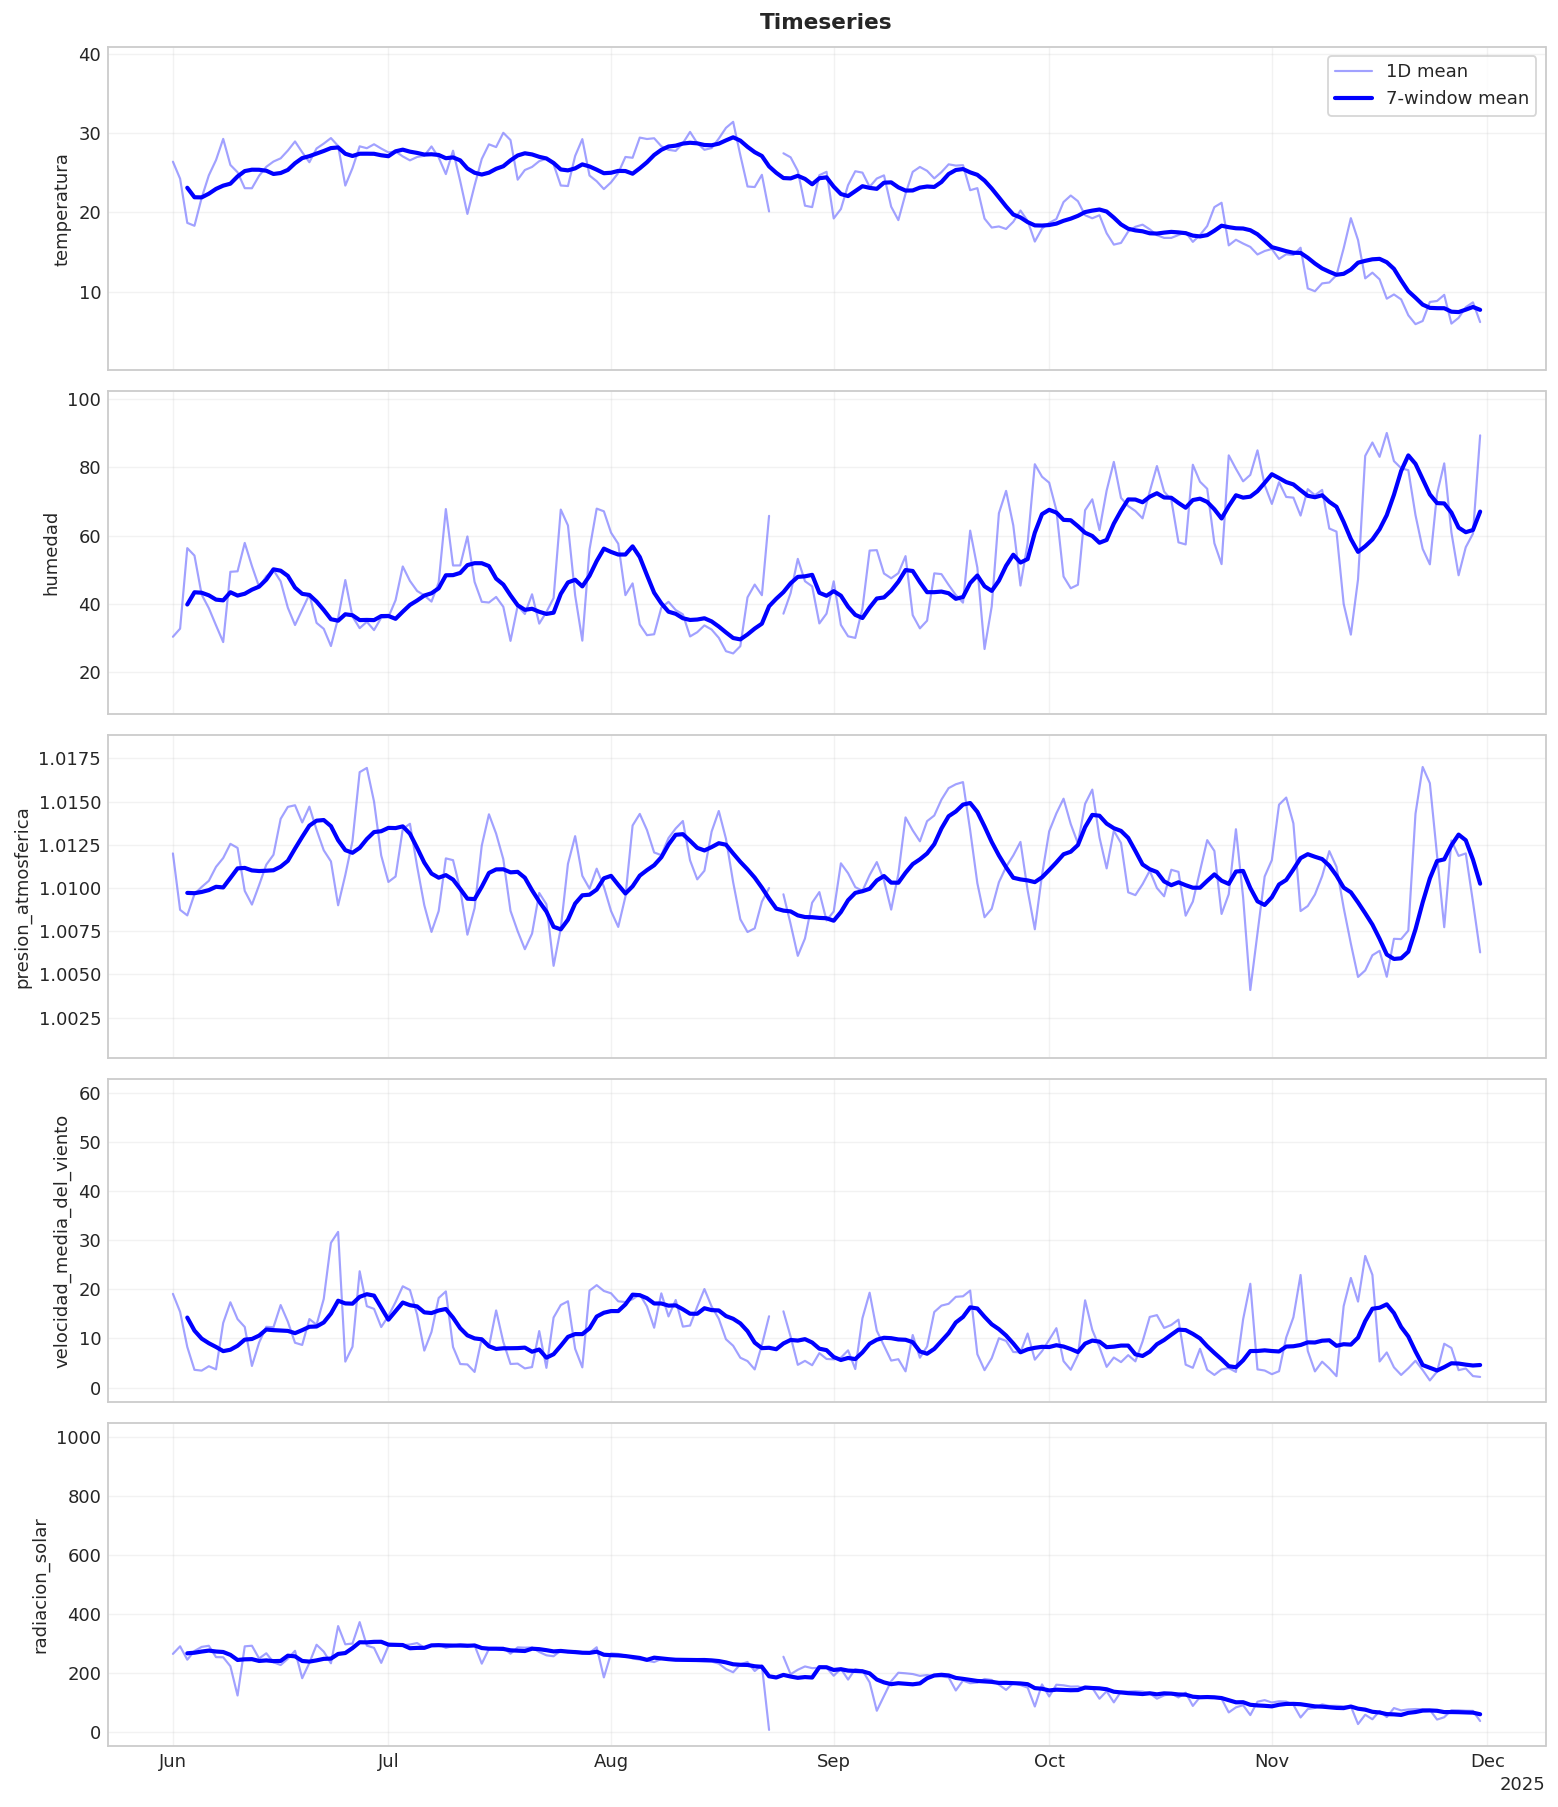


--- DISTRIBUTION PLOTS ---


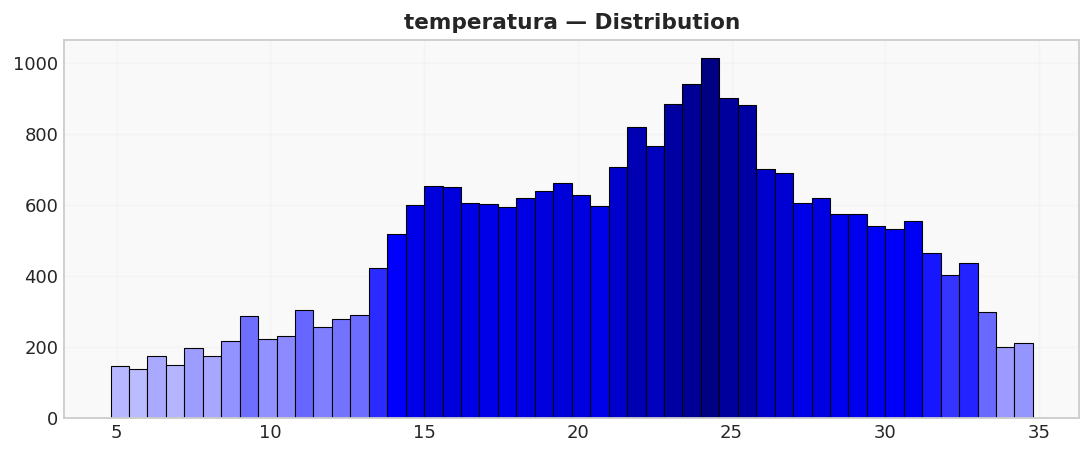

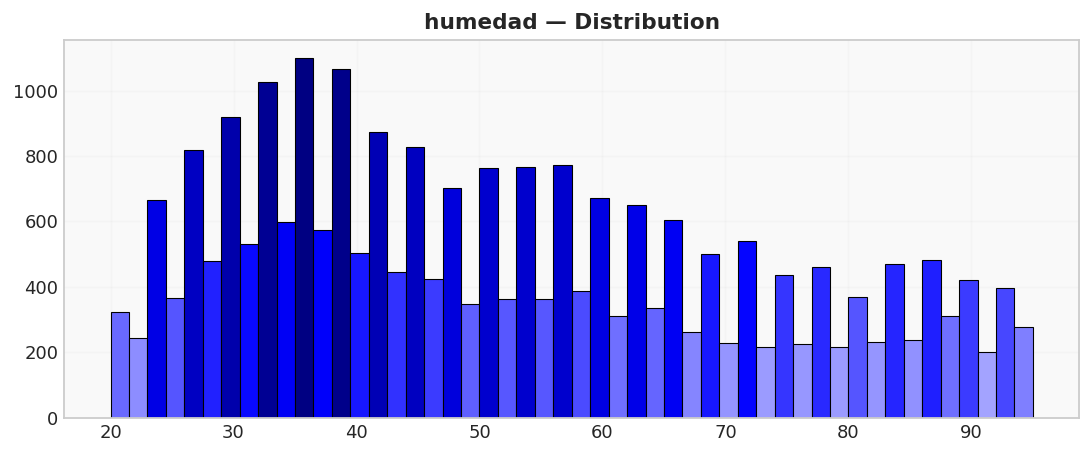

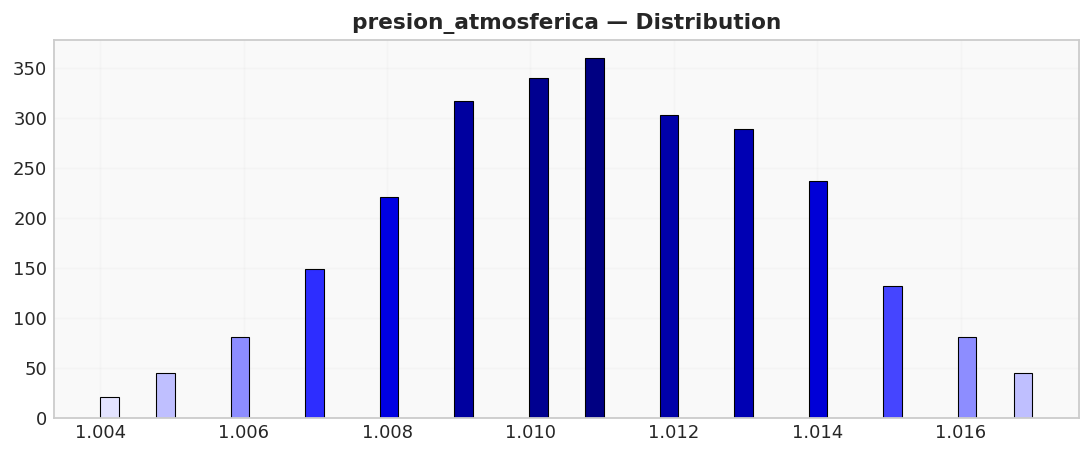

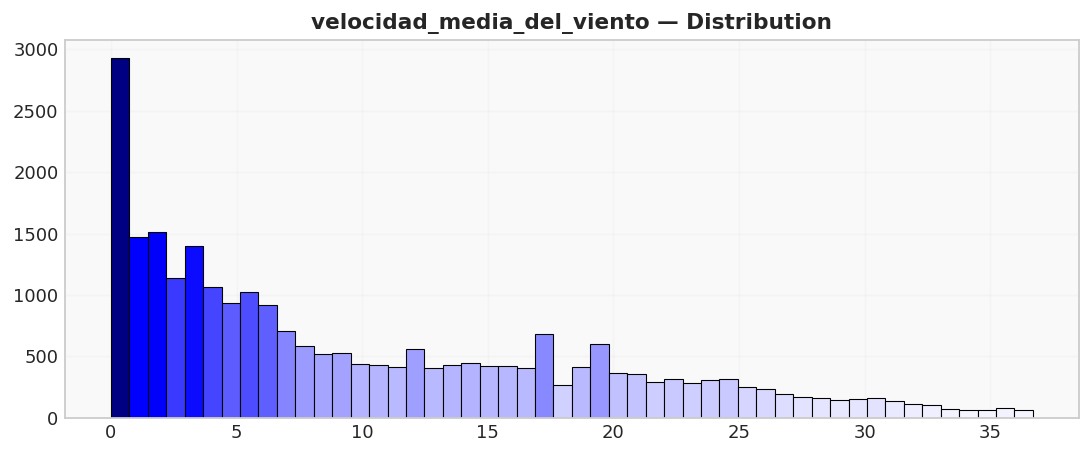

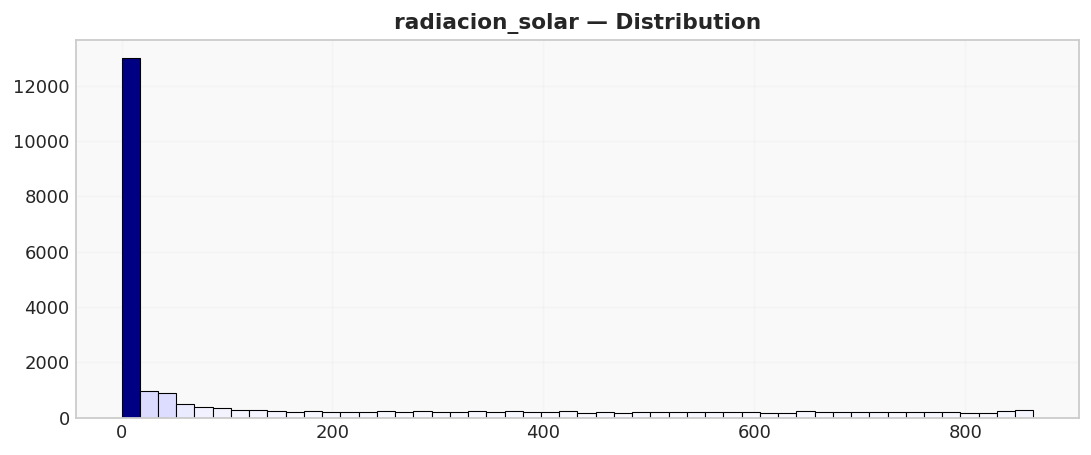


--- CORRELATION MATRIX (variables) ---


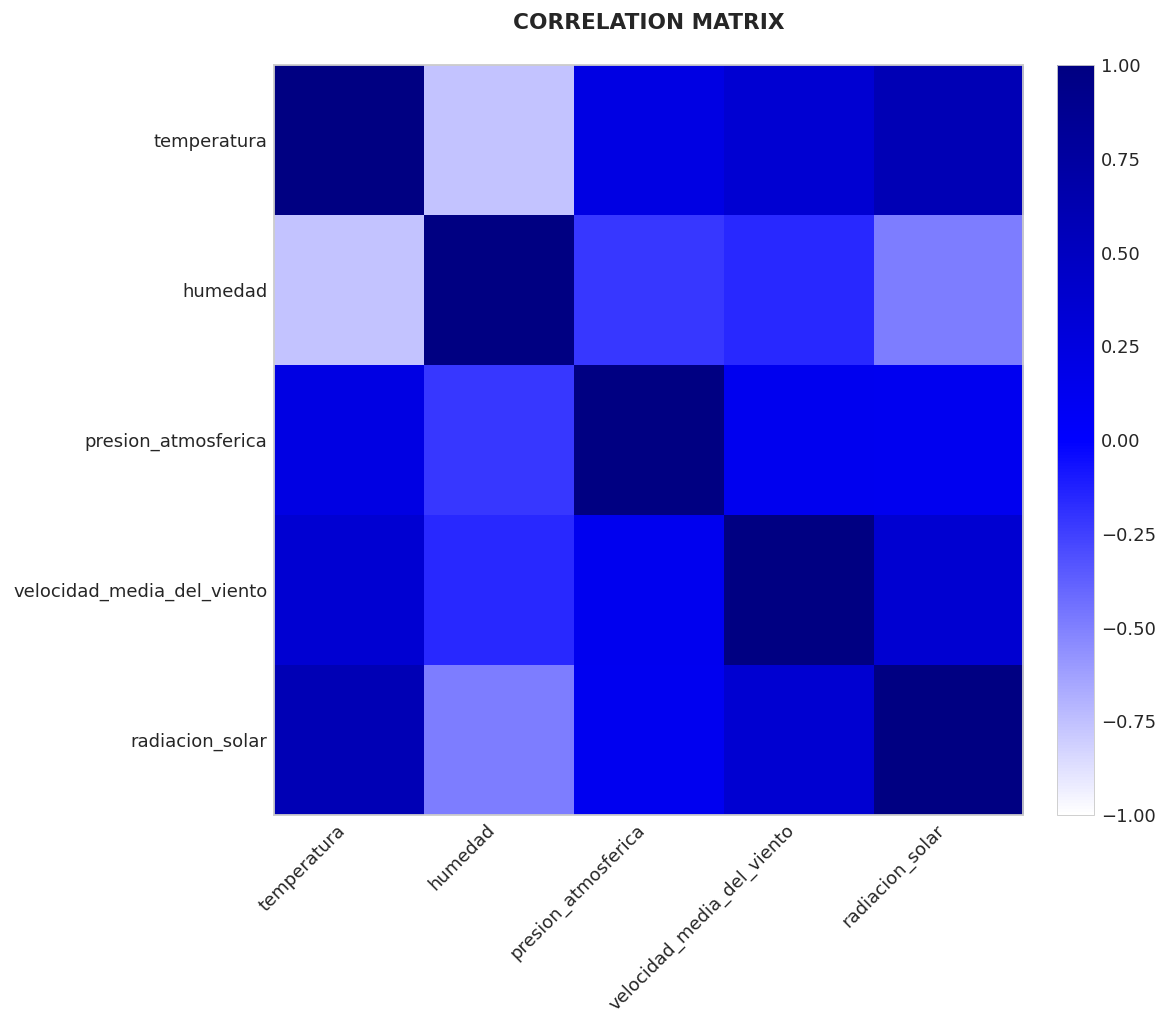


--- AVAILABILITY ---


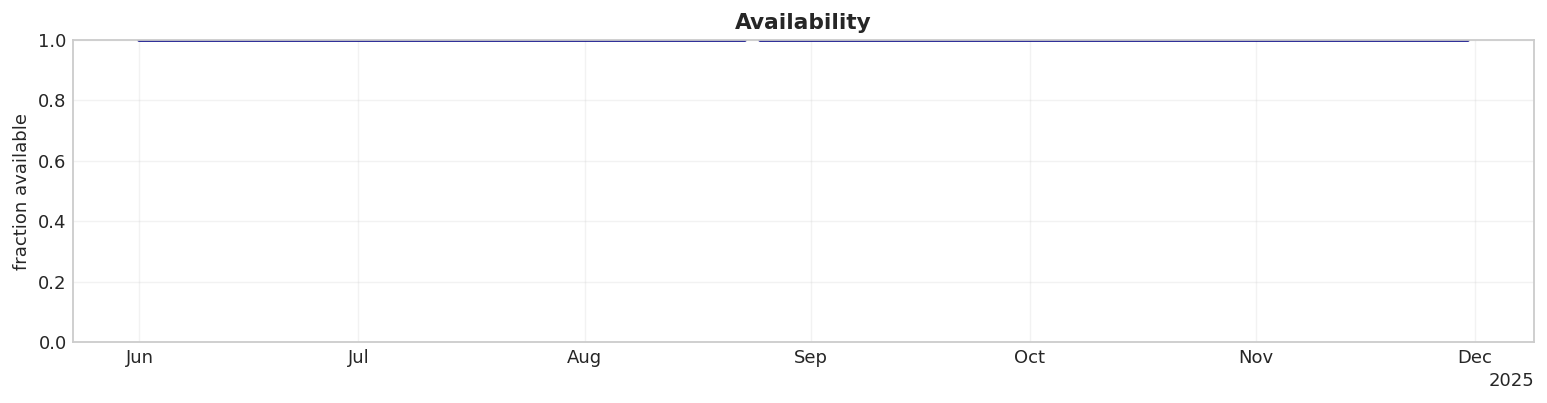

In [6]:
run_plots(ds_tharsis, "INCLINOMETERS", ref_var="x_mm_per_m", entity_dim="sensor")
run_plots(ds_canteras, "WEATHER STATION", ref_var="temperatura", entity_dim="sensor")